# Infra-Bench CLS — Paper Figures

Regenerates every figure in the manuscript and its Supporting Information from
the per-seed and aggregate result JSONs on Drive. Each figure renders inline
and writes a PNG to `RESULTS_BASE/figures/` under the exact filename the paper
uses, so the output drops straight into the manuscript's `figures/` folder.

**Runs in Google Colab.** The first cell mounts Drive; `RESULTS_BASE` points at
the evaluation output tree. There is no local script equivalent — this notebook
is the authoritative source for the manuscript figures.

**Scope.** Main-text Figures 3 through 10, Supporting Information Figures S1–S9
(confusion matrices) and S10 (training dynamics at 0.3x), and Supporting
Information Tables S10–S13. Manuscript Figures 1 and 2, the curation and
evaluation pipeline diagrams, are drawn by hand and are not produced here.

**Taxonomy.** The aggregate JSONs on Drive carry 13-class metrics. The setup
section re-fits them to the 10-class subset the paper reports, so every figure
below is 10-class — except per-region (Figure 9), which cannot be recomputed
from the stored aggregates and stays 13-class. See the re-fit cell for which
classes are dropped and why.

**How to use.** Run the setup cells once (mount, config, utilities, 10-class
re-fit), then run any figure cell on its own. The re-fit must run before any
figure cell, or that figure will silently show 13-class numbers.


## 1 · Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
import json

RESULTS_BASE = Path('/content/drive/MyDrive/infra_fm/results')

# ---- 1. raw structure: top-level files + one level into each subdir ----
print(f'RESULTS_BASE = {RESULTS_BASE}')
print(f'exists: {RESULTS_BASE.exists()}\n')

top_files, subdirs = [], []
for entry in sorted(RESULTS_BASE.iterdir()):
    (subdirs if entry.is_dir() else top_files).append(entry)

print(f'--- Top-level files ({len(top_files)}) ---')
for f in top_files:
    print(f'  {f.name}')

print(f'\n--- Subdirectories ({len(subdirs)}) ---')
for d in subdirs:
    seed_files = sorted(d.glob('*_seed*_results.json'))
    other = [p for p in d.iterdir() if p not in seed_files]
    print(f'  {d.name}/   ({len(seed_files)} seed files, {len(other)} other)')
    for p in sorted(other)[:4]:
        print(f'      {p.name}')

RESULTS_BASE = /content/drive/MyDrive/infra_fm/results
exists: True

--- Top-level files (0) ---

--- Subdirectories (31) ---
  figures/   (0 seed files, 18 other)
      FigS10_training-dynamics_0.3x.png
      FigS1_satlas_s1.png
      FigS2_satlas_s2.png
      FigS3_croma.png
  fm_eval_alphaearth_lp_0.3x_v1/   (3 seed files, 2 other)
      alphaearth_lp_0.3x_v1_aggregate.json
      confusion_matrix_alphaearth_lp_0.3x_v1_aggregate.png
  fm_eval_alphaearth_v2_spatial/   (3 seed files, 5 other)
      alphaearth_v2_aggregate.json
      confusion_matrix_alphaearth_v2_aggregate.png
      confusion_matrix_alphaearth_v2_seed161.png
      confusion_matrix_alphaearth_v2_seed271.png
  fm_eval_croma_finetune_0.3x_v1/   (3 seed files, 7 other)
      CROMA_SMOKE_seed314_finetune
      confusion_matrix_croma_finetune_0.3x_v1_aggregate.png
      croma_finetune_0.3x_v1_aggregate.json
      croma_finetune_0.3x_v1_seed161_finetune
  fm_eval_croma_finetune_v1/   (3 seed files, 10 other)
      CROMA_SMOKE

In [3]:
import glob
import json
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# =========================================================================
# configuration
# =========================================================================
# aggregate JSONs and per-seed run subdirs both live directly under RESULTS_BASE.
# figures are written to RESULTS_BASE / 'figures'.
RESULTS_BASE = Path('/content/drive/MyDrive/infra_fm/results')
OUTPUTS_DIR  = RESULTS_BASE / 'figures'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# canonical FM ordering used throughout the paper
FM_ORDER = [
    'SatlasPretrain S1',
    'SatlasPretrain S2',
    'CROMA',
    'Prithvi-EO-2.0',
    'AlphaEarth Foundations',
    'OlmoEarth v1.1-Base',
    'DINOv3 ViT-L/16',
    'Supervised ResNet-18',
    'Random Features',
]

# canonical colors per model
FM_COLORS = {
    'SatlasPretrain S1':      '#e67e22',   # orange
    'SatlasPretrain S2':      '#1f77b4',   # blue
    'CROMA':                  '#e6b800',   # yellow-gold
    'Prithvi-EO-2.0':         '#9467bd',   # purple
    'AlphaEarth Foundations': '#2ca02c',   # green
    'OlmoEarth v1.1-Base':    '#17becf',   # cyan
    'DINOv3 ViT-L/16':        '#d62728',   # red
    'Supervised ResNet-18':   "#b0b0b0",   # grey
    'Random Features':        '#8B4513',   # brown
}

# per-seed run subdirectories. (LP_1.0x, LP_0.3x, FT_1.0x, FT_0.3x)
# aggregate JSONs live INSIDE each of these dirs as <prefix>_aggregate.json.
RUN_DIR_MAP = {
    'SatlasPretrain S1':    ('fm_eval_satlas_s1_v2_spatial',         'fm_eval_satlas_s1_lp_0.3x_v1',
                             'fm_eval_satlas_s1_finetune_v1',        'fm_eval_satlas_s1_finetune_0.3x_v1'),
    'SatlasPretrain S2':    ('fm_eval_satlaspretrain_v2_spatial',    'fm_eval_satlas_s2_lp_0.3x_v1',
                             'fm_eval_satlas_s2_finetune_v1',        'fm_eval_satlas_s2_finetune_0.3x_v1'),
    'CROMA':                ('fm_eval_croma_v2_spatial',             'fm_eval_croma_lp_0.3x_v1',
                             'fm_eval_croma_finetune_v1',            'fm_eval_croma_finetune_0.3x_v1'),
    'Prithvi-EO-2.0':       ('fm_eval_prithvi_v2_spatial',           'fm_eval_prithvi_lp_0.3x_v1',
                             'fm_eval_prithvi_finetune_v1',          'fm_eval_prithvi_finetune_0.3x_v1'),
    'AlphaEarth Foundations': ('fm_eval_alphaearth_v2_spatial',      'fm_eval_alphaearth_lp_0.3x_v1',
                               None,                                  None),
    'OlmoEarth v1.1-Base':  ('fm_eval_olmoearth_lp_v1',              'fm_eval_olmoearth_lp_0.3x_v1',
                             'fm_eval_olmoearth_finetune_v1',        'fm_eval_olmoearth_finetune_0.3x_v1'),
    'DINOv3 ViT-L/16':      ('fm_eval_dinov3_lp_v1',                 'fm_eval_dinov3_lp_0.3x_v1',
                             'fm_eval_dinov3_finetune_v1',           'fm_eval_dinov3_finetune_0.3x_v1'),
    'Supervised ResNet-18': (None, None,
                             'fm_eval_resnet18_supervised_v1',       'fm_eval_resnet18_supervised_0.3x_v1'),
    'Random Features':      ('fm_eval_resnet18_random_features_v1',  'fm_eval_resnet18_random_features_0.3x_v1',
                             None,                                    None),
}

# map (model, mode, scale) -> the RUN_DIR_MAP tuple index that holds its aggregate.
_MODE_SCALE_TO_IDX = {
    ('LP', '1.0x'): 0, ('LP', '0.3x'): 1,
    ('FT', '1.0x'): 2, ('FT', '0.3x'): 3,
    ('Sup', '1.0x'): 2, ('Sup', '0.3x'): 3,   # supervised sits in the FT slots
}

In [4]:
# =========================================================================
# global PAPER STYLE
# =========================================================================
# one readable font baseline for every figure, so on-page (post-LaTeX-scaling)
# text stays legible. author figures near their final column/page width so point
# sizes survive into the compiled PDF roughly 1:1 instead of shrinking 2-2.5x.
def set_paper_style():
    plt.rcParams.update({
        'font.size':        15,   # base (tick labels, annotations default)
        'axes.titlesize':   16,   # per-axes titles
        'axes.labelsize':   15,   # x/y axis labels
        'xtick.labelsize':  13,
        'ytick.labelsize':  13,
        'legend.fontsize':  12,
        'legend.title_fontsize': 12,
        'figure.titlesize': 18,   # suptitle
        'savefig.dpi':      300,
        'figure.dpi':       110,
        'font.family':      'serif',
        'font.serif': ['Liberation Serif'] + plt.rcParams['font.serif']
    })

set_paper_style()


# =========================================================================
# loaders  (aggregates + per-seed run subdirs both under RESULTS_BASE)
# =========================================================================
def load_agg(model, mode, scale):
    """Load the aggregate JSON living inside a condition's run subdir."""
    idx = _MODE_SCALE_TO_IDX.get((mode, scale))
    if idx is None:
        return None
    subdirs = RUN_DIR_MAP.get(model)
    if subdirs is None:
        return None
    subdir = subdirs[idx]
    if subdir is None:
        return None
    hits = sorted(glob.glob(str(RESULTS_BASE / subdir / '*_aggregate.json')))
    if not hits:
        print(f'  ! no *_aggregate.json in {subdir}/')
        return None
    if len(hits) > 1:
        print(f'  ! multiple aggregates in {subdir}/, using {Path(hits[0]).name}')
    with open(hits[0]) as f:
        return json.load(f)


def load_val_curves(subdir):
    """Per-epoch val_macro_f1 across seeds -> array (n_seeds, n_epochs) or None."""
    if subdir is None:
        return None
    files = sorted(glob.glob(str(RESULTS_BASE / subdir / '*_seed*_results.json')))
    if not files:
        return None
    curves = []
    for f in files:
        with open(f) as fp:
            d = json.load(fp)
        inner = d.get('finetune') or d.get('linear_probe')
        if inner is None:
            continue
        vals = [h.get('val_macro_f1', 0.0) for h in inner.get('history', [])]
        if vals:
            curves.append(vals)
    if not curves:
        return None
    min_len = min(len(c) for c in curves)
    return np.array([c[:min_len] for c in curves])


def load_best_epoch_mean(subdir):
    if subdir is None:
        return None
    files = sorted(glob.glob(str(RESULTS_BASE / subdir / '*_seed*_results.json')))
    if not files:
        return None
    epochs = []
    for f in files:
        with open(f) as fp:
            d = json.load(fp)
        inner = d.get('finetune') or d.get('linear_probe')
        if inner is not None and inner.get('best_epoch') is not None:
            epochs.append(inner['best_epoch'])
    return float(np.mean(epochs)) if epochs else None


def _best_condition_agg(fm):
    """Aggregate JSON for each FM's best-adaptation condition (for E1/E2)."""
    best = {
        'SatlasPretrain S1':      ('FT', '1.0x'),
        'SatlasPretrain S2':      ('FT', '1.0x'),
        'CROMA':                  ('FT', '1.0x'),
        'Prithvi-EO-2.0':         ('FT', '1.0x'),
        'AlphaEarth Foundations': ('LP', '1.0x'),
        'OlmoEarth v1.1-Base':    ('FT', '1.0x'),
        'DINOv3 ViT-L/16':        ('FT', '1.0x'),
        'Supervised ResNet-18':   ('Sup', '1.0x'),
        'Random Features':        ('LP', '1.0x'),
    }
    mode, scale = best[fm]
    return load_agg(fm, mode, scale)

print('Style + loaders ready.')

Style + loaders ready.


In [5]:
# =========================================================================
# 10-CLASS TAXONOMY RE-FIT
# =========================================================================
# the aggregate JSONs on Drive were computed on the original 13-class
# taxonomy. this cell defines the 10-class subset used by the revised paper
# and monkey-patches load_agg() / _best_condition_agg() to recompute
# macro F1, weighted F1, and per-sector F1 on the 10-class subset before
# returning the aggregate dict. downstream figure functions do not need
# to be modified -- they call load_agg() as usual and receive 10-class
# values transparently.
#
# excluded classes (dropped from all aggregate metrics):
#   idx 5   energy.generation.wind_farm    (n=3 per seed)
#   idx 7   water.water_works              (n=118 per seed)
#   idx 11  transport.port_terminal        (n=3 per seed)
#
# what THIS cell changes on the loaded aggregate dict:
#   - test_macro_f1 (mean / std / per_seed)     <- recomputed on 10 KEEP
#   - test_weighted_f1                          <- added (was not in agg)
#   - per_sector_f1                             <- recomputed on retained
#                                                  sector classes
#
# what this DOES NOT change:
#   - per_class_f1     : per-class F1 values are invariant to which OTHER
#                        classes are aggregated over, so this stays as-is
#   - per_region_f1    : per-region per-class F1s are not stored in the
#                        aggregate JSONs, so we can't recompute this on 10
#                        classes -- it stays 13-class. fig E2 will need a
#                        caption note (or use with awareness).
#   - test_accuracy    : requires per-seed confusion-matrix diagonal on
#                        the retained classes, which the aggregate does
#                        not carry. stays 13-class (unused by main figs).

import math
from statistics import mean as _stats_mean

# per-seed class support counts (deterministic across seeds under the
# spatial split -- verified to equal per-seed confusion-matrix row sums).
CLASS_COUNTS_13 = [105, 141, 511, 70, 98, 3, 228, 118, 574, 125, 737, 3, 100]
EXCLUDED_IDX   = {5, 7, 11}                                  # wind_farm, water_works, port_terminal
KEEP_IDX       = [i for i in range(13) if i not in EXCLUDED_IDX]
DENOM_10       = sum(CLASS_COUNTS_13[i] for i in KEEP_IDX)   # 2689

# sector -> retained class indices. keys match the aggregate JSON's per_sector_f1 keys.
# display labels for all 13 classes; we slice to the retained 10 via KEEP_IDX.
_CLASS_DISPLAY_ALL_13 = [
    'Transmission Substation', 'Distribution Substation', 'Distribution (Other)',
    'Power Plant', 'Solar Farm', 'Wind Farm',
    'Wastewater Plant', 'Water Works', 'Storage Tank',
    'Airport', 'Train Station', 'Port Terminal',
    'Data Center',
]
CLASS_DISPLAY_NAMES_10 = [_CLASS_DISPLAY_ALL_13[i] for i in KEEP_IDX]

SECTOR_CLASSES_10 = {
    'energy':    [0, 1, 2, 3, 4],   # tx_sub, dx_sub, dx_other, power_plant, solar_farm
    'water':     [6, 8],            # wastewater, storage_tank
    'transport': [9, 10],           # airport, train_station
    'telecom':   [12],              # data_center
}

def _pop_std(xs):
    m = _stats_mean(xs)
    return math.sqrt(sum((x - m) ** 2 for x in xs) / len(xs))

def _refit_agg_10class(agg):
    """Mutate an aggregate JSON dict in place so its top-level metrics reflect
    the 10-class taxonomy. Idempotent."""
    if agg is None:
        return None
    if agg.get('_refit_marker') == '10class':
        return agg
    pcf = agg.get('per_class_f1')
    if not pcf or len(pcf) != 13:
        # unknown schema -- return unchanged rather than corrupt
        return agg
    n_seeds = len(pcf[0]['per_seed'])

    # per-seed 10-class macro F1 and weighted F1
    macro_per_seed = []
    wgt_per_seed   = []
    for s in range(n_seeds):
        f1s_s = [pcf[i]['per_seed'][s] for i in range(13)]
        macro_per_seed.append(_stats_mean(f1s_s[i] for i in KEEP_IDX))
        wgt_per_seed.append(
            sum(CLASS_COUNTS_13[i] * f1s_s[i] for i in KEEP_IDX) / DENOM_10
        )
    agg['test_macro_f1'] = {
        'mean':     _stats_mean(macro_per_seed),
        'std':      _pop_std(macro_per_seed),
        'per_seed': macro_per_seed,
    }
    agg['test_weighted_f1'] = {
        'mean':     _stats_mean(wgt_per_seed),
        'std':      _pop_std(wgt_per_seed),
        'per_seed': wgt_per_seed,
    }

    # per-sector recompute on retained classes only
    new_sector = {}
    for sect, idxs in SECTOR_CLASSES_10.items():
        per_seed = []
        for s in range(n_seeds):
            f1s_s = [pcf[i]['per_seed'][s] for i in idxs]
            per_seed.append(_stats_mean(f1s_s))
        new_sector[sect] = {
            'n':             sum(CLASS_COUNTS_13[i] for i in idxs),
            'mean_macro_f1': _stats_mean(per_seed),
            'std_macro_f1':  _pop_std(per_seed),
            'per_seed':      per_seed,
        }
    agg['per_sector_f1'] = new_sector
    agg['_refit_marker'] = '10class'
    return agg

# ---- monkey-patch loaders so every downstream figure call gets 10-class data ----
_original_load_agg          = load_agg
_original_best_condition_agg = _best_condition_agg

def load_agg(model, mode, scale):
    return _refit_agg_10class(_original_load_agg(model, mode, scale))

def _best_condition_agg(fm):
    return _refit_agg_10class(_original_best_condition_agg(fm))

print('10-class re-fit installed.')
print(f'  Excluded (idx):    {sorted(EXCLUDED_IDX)}  ({[["wind_farm","water_works","port_terminal"][j] for j,i in enumerate(sorted(EXCLUDED_IDX))]})')
print(f'  Retained (idx):    {KEEP_IDX}')
print(f'  Test denom:        {DENOM_10} tiles/seed  (was 2813)')
print(f'  Per_sector n:      transport={sum(CLASS_COUNTS_13[i] for i in SECTOR_CLASSES_10["transport"])},'
      f' telecom={sum(CLASS_COUNTS_13[i] for i in SECTOR_CLASSES_10["telecom"])},'
      f' water={sum(CLASS_COUNTS_13[i] for i in SECTOR_CLASSES_10["water"])},'
      f' energy={sum(CLASS_COUNTS_13[i] for i in SECTOR_CLASSES_10["energy"])}')

# ---- sanity check against known 10-class values ----
_expected = {
    ('DINOv3 ViT-L/16',  'FT', '1.0x'): (0.579, 0.627),
    ('SatlasPretrain S2','FT', '1.0x'): (0.559, 0.601),
    ('CROMA',            'FT', '1.0x'): (0.341, 0.343),
    ('AlphaEarth Foundations', 'LP', '1.0x'): (0.266, 0.268),
}
print('\nSanity check (macro / weighted; both should match to 3 decimals):')
for (m, mo, sc), (m_exp, w_exp) in _expected.items():
    d = load_agg(m, mo, sc)
    if d is None:
        print(f'  {m:<24} {mo}/{sc}: agg missing')
        continue
    got_m = d['test_macro_f1']['mean']
    got_w = d['test_weighted_f1']['mean']
    tag_m = 'OK' if abs(got_m - m_exp) < 0.001 else 'MISMATCH'
    tag_w = 'OK' if abs(got_w - w_exp) < 0.001 else 'MISMATCH'
    print(f'  {m:<24} {mo}/{sc}: macro {got_m:.3f} (expect {m_exp:.3f}) {tag_m}  |  wgt {got_w:.3f} (expect {w_exp:.3f}) {tag_w}')

10-class re-fit installed.
  Excluded (idx):    [5, 7, 11]  (['wind_farm', 'water_works', 'port_terminal'])
  Retained (idx):    [0, 1, 2, 3, 4, 6, 8, 9, 10, 12]
  Test denom:        2689 tiles/seed  (was 2813)
  Per_sector n:      transport=862, telecom=100, water=802, energy=925

Sanity check (macro / weighted; both should match to 3 decimals):
  DINOv3 ViT-L/16          FT/1.0x: macro 0.579 (expect 0.579) OK  |  wgt 0.627 (expect 0.627) OK
  SatlasPretrain S2        FT/1.0x: macro 0.559 (expect 0.559) OK  |  wgt 0.601 (expect 0.601) OK
  CROMA                    FT/1.0x: macro 0.341 (expect 0.341) OK  |  wgt 0.343 (expect 0.343) OK
  AlphaEarth Foundations   LP/1.0x: macro 0.266 (expect 0.266) OK  |  wgt 0.268 (expect 0.268) OK


In [6]:
# 1. is the running copy the fixed one?
print(f'FM_ORDER holds {len(FM_ORDER)} models')
for _m in FM_ORDER:
    print('    ', _m)
if len(FM_ORDER) == 9:
    print('  -> config cell intact. The fix is live in this session.')
else:
    print('  -> STALE: this copy still has the old Figure 5 cell rebinding FM_ORDER.')

# 2. which notebook file is this session actually executing?
try:
    from google.colab import _message
    _meta = _message.blocking_request('get_ipynb', timeout_sec=10)['ipynb']['metadata']
    print(f"\nnotebook: {_meta.get('colab', {}).get('name', '<unnamed>')}")
except Exception as _e:
    print(f'\nnotebook: <could not determine: {_e}>')

# 3. what do Figures 6, 8 and 9 actually receive per model?
print('\nper-model load check:')
for _m in FM_ORDER:
    _d = _best_condition_agg(_m)
    if _d is None:
        print(f'  {_m:<24} -> None   *** dropped from fig 8/9 ***')
        continue
    _pcf = _d.get('per_class_f1')
    _sec = _d.get('per_sector_f1')
    _reg = _d.get('per_region_f1')
    print(f'  {_m:<24} ok   per_class={len(_pcf) if _pcf else None}'
          f'   sectors={sorted(_sec) if _sec else None}'
          f'   regions={len(_reg) if _reg else None}'
          f'   refit={_d.get("_refit_marker")}')

# 4. and what Figure 6 receives for its four bars per model
print('\nfigure 6 per-bar check:')
for _m in FM_ORDER:
    _got = [f'{_mo}/{_sc}' for _mo, _sc in
            (('LP', '1.0x'), ('LP', '0.3x'), ('FT', '1.0x'), ('FT', '0.3x'),
             ('Sup', '1.0x'), ('Sup', '0.3x'))
            if load_agg(_m, _mo, _sc) is not None]
    print(f'  {_m:<24} {_got}')


FM_ORDER holds 9 models
     SatlasPretrain S1
     SatlasPretrain S2
     CROMA
     Prithvi-EO-2.0
     AlphaEarth Foundations
     OlmoEarth v1.1-Base
     DINOv3 ViT-L/16
     Supervised ResNet-18
     Random Features
  -> config cell intact. The fix is live in this session.

notebook: <could not determine: 'NoneType' object is not subscriptable>

per-model load check:
  SatlasPretrain S1        ok   per_class=13   sectors=['energy', 'telecom', 'transport', 'water']   regions=7   refit=10class
  SatlasPretrain S2        ok   per_class=13   sectors=['energy', 'telecom', 'transport', 'water']   regions=7   refit=10class
  CROMA                    ok   per_class=13   sectors=['energy', 'telecom', 'transport', 'water']   regions=7   refit=10class
  Prithvi-EO-2.0           ok   per_class=13   sectors=['energy', 'telecom', 'transport', 'water']   regions=7   refit=10class
  AlphaEarth Foundations   ok   per_class=13   sectors=['energy', 'telecom', 'transport', 'water']   regions=7   ref

## 2 — Main-text figures


### Figure 3 — per-class F1 heatmap across all models


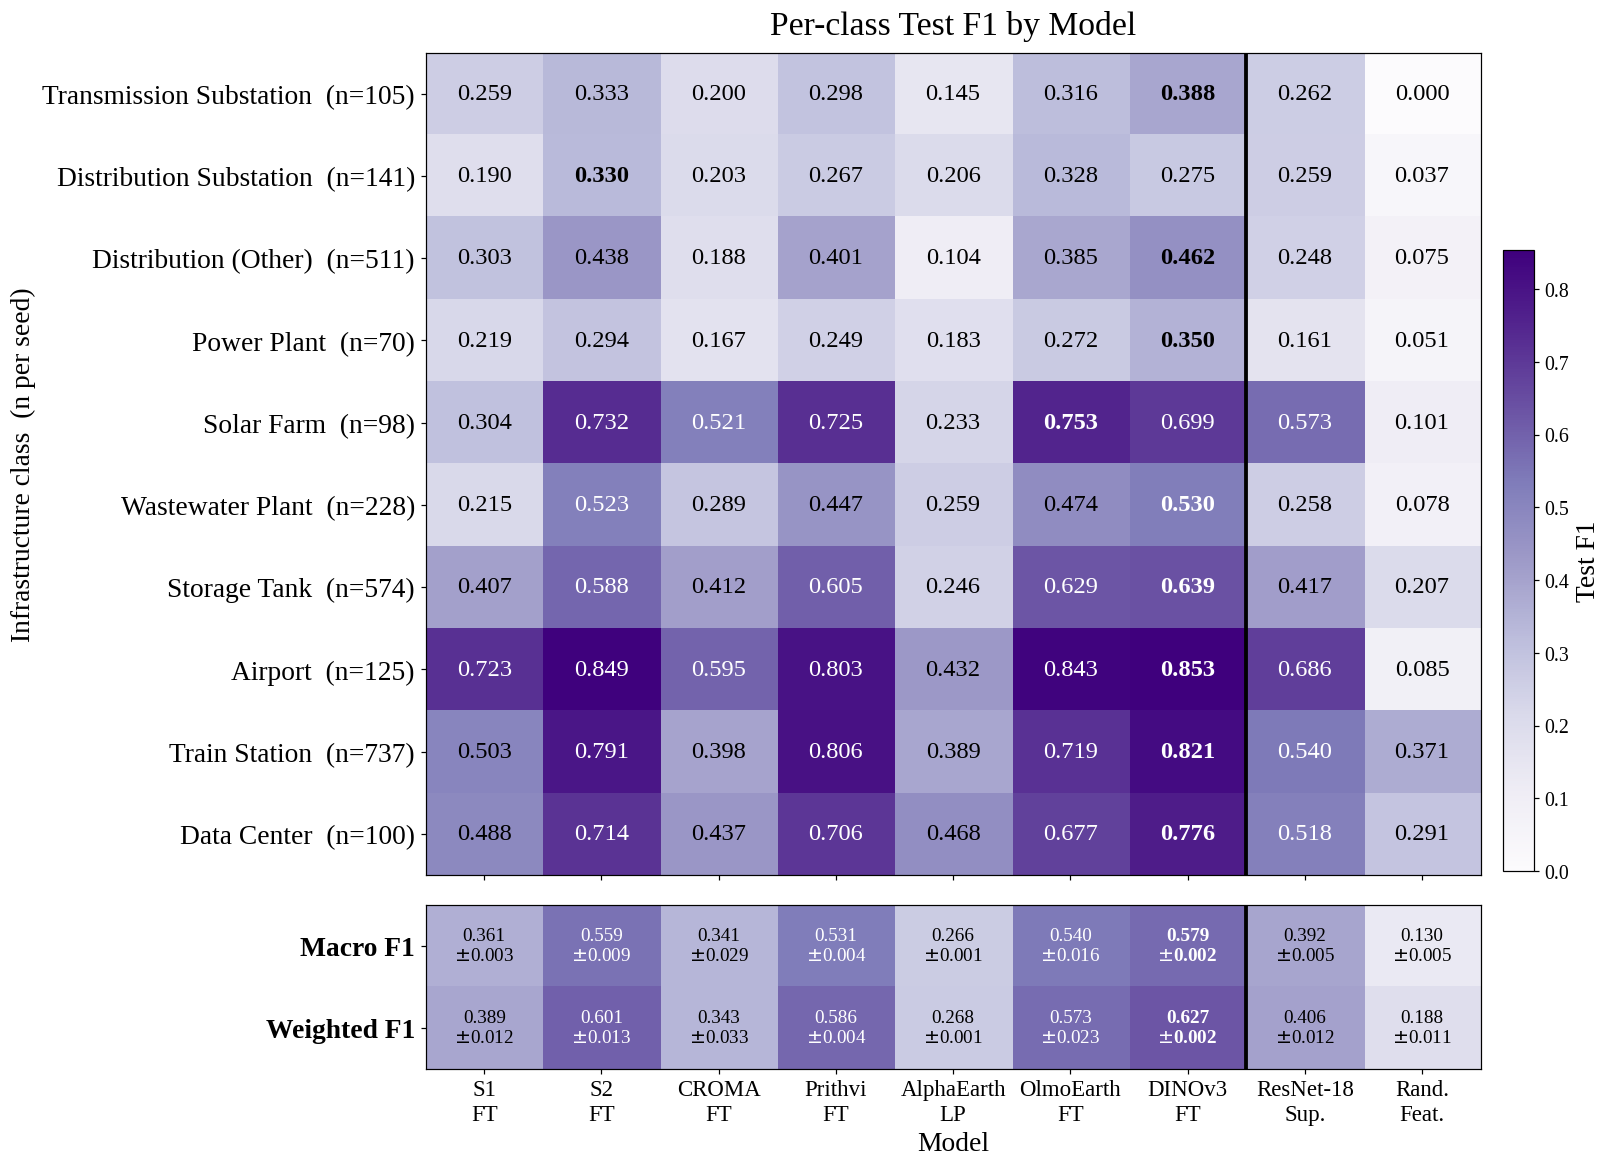

In [7]:
# =========================================================================
# figure: Per-class Test F1 heatmap (replaces Table 1 in main text)
# reads from _best_condition_agg() so values match Table 1 exactly.
# class cells: per-class F1 (mean, sliced to 10 via KEEP_IDX).
# summary rows: macro & weighted F1 (mean ± std across 3 seeds).
# bold = best FM per row (baselines excluded). full mean±std table -> SI.
# =========================================================================
def figure_3_perclass_heatmap():
    from matplotlib.gridspec import GridSpec

    # column order = FM_ORDER (baselines last, matching Table 1)
    col_labels = {
        'SatlasPretrain S1':'S1\nFT', 'SatlasPretrain S2':'S2\nFT', 'CROMA':'CROMA\nFT',
        'Prithvi-EO-2.0':'Prithvi\nFT', 'AlphaEarth Foundations':'AlphaEarth\nLP',
        'OlmoEarth v1.1-Base':'OlmoEarth\nFT', 'DINOv3 ViT-L/16':'DINOv3\nFT',
        'Supervised ResNet-18':'ResNet-18\nSup.', 'Random Features':'Rand.\nFeat.',
    }
    models = [
    'SatlasPretrain S1', 'SatlasPretrain S2', 'CROMA', 'Prithvi-EO-2.0',
    'AlphaEarth Foundations', 'OlmoEarth v1.1-Base', 'DINOv3 ViT-L/16',
    'Supervised ResNet-18', 'Random Features',
]
    n_fm_cols = models.index('Supervised ResNet-18')   # divider before baselines
    xtick = [col_labels[m] for m in models]

    # class rows: display names + per-seed n, from KEEP_IDX
    classes = [f"{CLASS_DISPLAY_NAMES_10[k]}  (n={CLASS_COUNTS_13[KEEP_IDX[k]]})"
               for k in range(len(KEEP_IDX))]

    # build per-class matrix (rows=class, cols=model), sliced to 10
    data   = np.full((len(KEEP_IDX), len(models)), np.nan)
    macro  = np.full(len(models), np.nan); macro_s  = np.zeros(len(models))
    weight = np.full(len(models), np.nan); weight_s = np.zeros(len(models))
    for j, m in enumerate(models):
        agg = _best_condition_agg(m)
        if agg is None:
            print(f'  ! no agg for {m}'); continue
        pcf = agg.get('per_class_f1')            # 13-element list
        if pcf is not None:
            for k, idx13 in enumerate(KEEP_IDX):
                data[k, j] = pcf[idx13]['mean_f1']
        mf = agg.get('test_macro_f1');  wf = agg.get('test_weighted_f1')
        if mf: macro[j], macro_s[j]   = mf['mean'], mf.get('std', 0.0)
        if wf: weight[j], weight_s[j] = wf['mean'], wf.get('std', 0.0)

    summ   = np.vstack([macro, weight])
    summ_s = np.vstack([macro_s, weight_s])
    summ_labels = ['Macro F1', 'Weighted F1']
    FM_COLS = list(range(n_fm_cols))             # leader = best among FMs only

    cmap = plt.get_cmap('Purples')
    vmax = np.nanmax(data)
    def tc(v): return 'white' if v > 0.60 * vmax else 'black'

    fig = plt.figure(figsize=(13, 12))
    gs  = GridSpec(2, 1, height_ratios=[len(KEEP_IDX), 2], hspace=0.06, figure=fig)
    ax  = fig.add_subplot(gs[0]); axs = fig.add_subplot(gs[1], sharex=ax)

    # --- main per-class block ---
    im = ax.imshow(data, cmap=cmap, vmin=0, vmax=vmax, aspect='auto')
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=18)
    ax.set_xticks(range(len(models))); ax.tick_params(labelbottom=False)
    for i in range(len(classes)):
        row_fm = [(j, data[i, j]) for j in FM_COLS if not np.isnan(data[i, j])]
        leader = max(row_fm, key=lambda t: t[1])[0] if row_fm else -1
        for j in range(len(models)):
            v = data[i, j]
            if np.isnan(v): continue
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', color=tc(v),
                    fontsize=16, fontweight='bold' if j == leader else 'normal')
    ax.axvline(n_fm_cols - 0.5, color='black', lw=2.5)
    ax.set_ylabel('Infrastructure class  (n per seed)', fontsize=18)
    ax.set_title('Per-class Test F1 by Model', fontsize=22, pad=12)

    # --- summary block ---
    axs.imshow(summ, cmap=cmap, vmin=0, vmax=vmax, aspect='auto')
    axs.set_yticks(range(2)); axs.set_yticklabels(summ_labels, fontsize=18, fontweight='bold')
    axs.set_xticks(range(len(models))); axs.set_xticklabels(xtick, fontsize=15)
    for i in range(2):
        row_fm = [(j, summ[i, j]) for j in FM_COLS if not np.isnan(summ[i, j])]
        leader = max(row_fm, key=lambda t: t[1])[0] if row_fm else -1
        for j in range(len(models)):
            v = summ[i, j]
            if np.isnan(v): continue
            axs.text(j, i, f'{v:.3f}\n$\\pm${summ_s[i, j]:.3f}', ha='center', va='center',
                     color=tc(v), fontsize=12.5, fontweight='bold' if j == leader else 'normal')
    axs.axvline(n_fm_cols - 0.5, color='black', lw=2.5)
    axs.set_xlabel('Model', fontsize=18)

    cbar = fig.colorbar(im, ax=[ax, axs], fraction=0.028, pad=0.02)
    cbar.set_label('Test F1', fontsize=18)
    fig.savefig(OUTPUTS_DIR / 'fig3_perclass_heatmap_across_f1s.png', dpi=300, bbox_inches='tight')
    plt.show()

figure_3_perclass_heatmap()

### Figure 4 — all 30 conditions, sorted by test macro F1


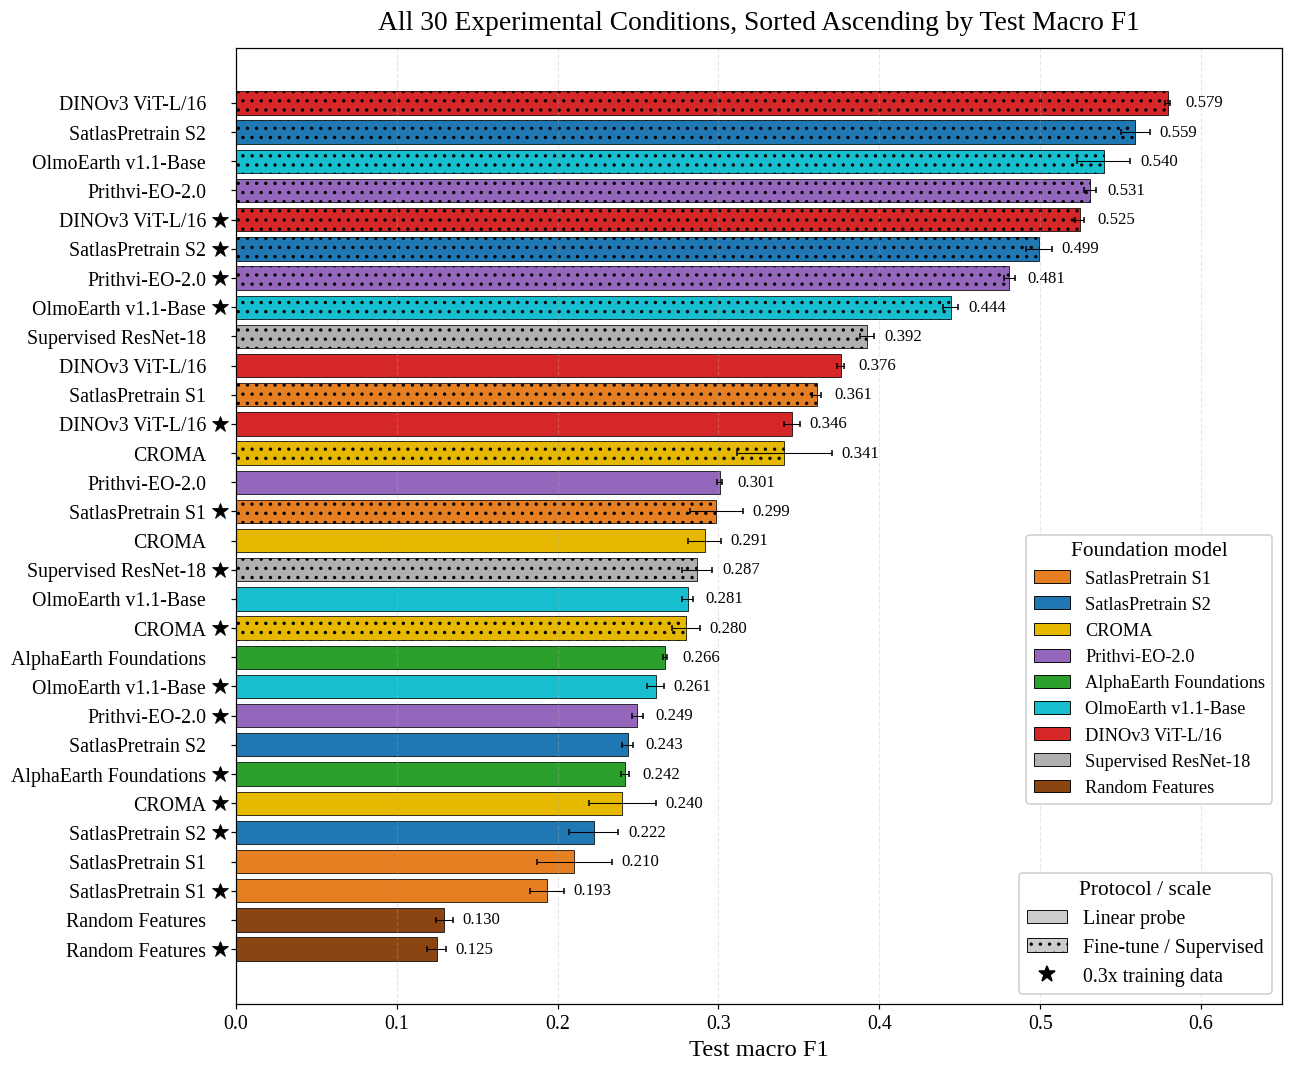

In [8]:
def figure_4_all_conditions():
    entries = []
    for model in FM_ORDER:
        if model == 'Supervised ResNet-18':
            modes = ('Sup',)
        elif model in ('AlphaEarth Foundations', 'Random Features'):
            modes = ('LP',)
        else:
            modes = ('LP', 'FT')
        for mode in modes:
            for scale in ('1.0x', '0.3x'):
                d = load_agg(model, mode, scale)
                if d is None:
                    continue
                entries.append({'model': model, 'mode': mode, 'scale': scale,
                                'mean': d['test_macro_f1']['mean'],
                                'std':  d['test_macro_f1']['std']})
    entries.sort(key=lambda x: x['mean'])

    fig, ax = plt.subplots(figsize=(12, 10))
    plt.subplots_adjust(left=0.28)
    y = np.arange(len(entries))

    # hatch encodes protocol: dotted = FT (and Supervised, which shares FT's
    # trainable-backbone protocol), solid = LP. star marks 0.3x data scale.
    def hatch_for(mode):
        return '..' if mode in ('FT', 'Sup') else ''

    for i, e in enumerate(entries):
        color = FM_COLORS[e['model']]
        ax.barh(i, e['mean'], xerr=e['std'], color=color,
                edgecolor='black', linewidth=0.5, hatch=hatch_for(e['mode']),
                error_kw={'ecolor': 'black', 'capsize': 2, 'linewidth': 0.7})
        # star in the left margin (outside plot area) for 0.3x rows
        if e['scale'] == '0.3x':
            ax.plot(-0.01, i, marker='*', markersize=11, color='black',
                    markeredgecolor='black', markeredgewidth=0.5,
                    clip_on=False, zorder=6)
        # value label, nudged right of the error bar
        ax.text(e['mean'] + max(e['std'], 0.005) + 0.006, i,
                f"{e['mean']:.3f}", va='center', fontsize=11)

    ax.set_yticks(y)
    ax.set_yticklabels([e['model'] for e in entries], fontsize=13)
    ax.tick_params(axis='y', pad=16)
    ax.set_xlabel('Test macro F1', fontsize=16)
    ax.set_xlim(0, 0.65)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_title('All 30 Experimental Conditions, Sorted Ascending by Test Macro F1',
                 fontsize=18, pad=12)

        # legend 1: model colors (upper of two stacked legends in bottom-right)
    model_handles = [
        Patch(facecolor=FM_COLORS[fm], edgecolor='black', linewidth=0.6, label=fm)
        for fm in FM_ORDER
    ]
    model_legend = ax.legend(
        handles=model_handles,
        loc='lower right',
        bbox_to_anchor=(1.0, 0.20),   # tweak this y if it overlaps bars
        fontsize=12,
        framealpha=0.95,
        title='Foundation model',
        title_fontsize=14,
    )
    ax.add_artist(model_legend)   # keep this legend when we add the second

    # legend 2: protocol / scale (lower of the two)
    protocol_handles = [
        Patch(facecolor='#cccccc', edgecolor='black', linewidth=0.6, label='Linear probe'),
        Patch(facecolor='#cccccc', edgecolor='black', linewidth=0.6, hatch='..', label='Fine-tune / Supervised'),
        Line2D([0], [0], marker='*', color='none', markerfacecolor='black',
               markeredgecolor='black', markersize=11, label='0.3x training data'),
    ]
    ax.legend(
        handles=protocol_handles,
        loc='lower right',
        bbox_to_anchor=(1.0, 0.0),
        fontsize=13,
        framealpha=0.95,
        title='Protocol / scale',
        title_fontsize=14,
    )

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'fig4_all_conditions.png', dpi=300, bbox_inches='tight')
    plt.show()

figure_4_all_conditions()

### Figure 5 — the LP to FT flip

Dumbbell plot of each model's move from linear probing to fine-tuning, against the supervised baseline. Reads from the patched `load_agg()`, so the values match Table 1.


Baseline (Supervised ResNet-18 FT 1.0x) macro F1 = 0.3921909735963698
  DINOv3 ViT-L/16        LP=0.37609484073895716  FT=0.5792118367110837
  SatlasPretrain S2      LP=0.24347408681117666  FT=0.5591997071975423
  OlmoEarth v1.1-Base    LP=0.28089496548988013  FT=0.5395027906032045
  Prithvi-EO-2.0         LP=0.30069981704760657  FT=0.5307365435974104
  SatlasPretrain S1      LP=0.21031898691747297  FT=0.3609519995106139
  CROMA                  LP=0.2914517844388335  FT=0.3409842103567273


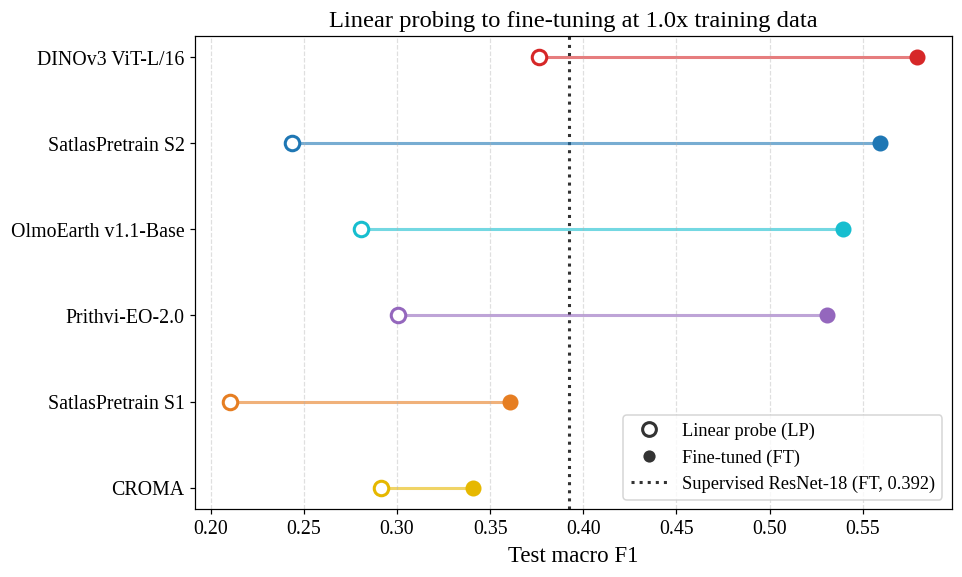

In [9]:
# =========================================================================
# figure: LP -> FT flip (dumbbell / lollipop), 10-class, vs supervised baseline
# reads from the monkey-patched load_agg() so values match Table 1 exactly.
# =========================================================================
import matplotlib.pyplot as plt

# the six models that have BOTH an LP and an FT run -- AlphaEarth and Random
# Features are LP-only, and the supervised ResNet is the dotted reference line.
#
# NOTE: keep this list under its own name, and do not rename FM_ORDER to match
# it. Figures 4, 6, 8, 9, 10 and S10 all iterate the global FM_ORDER defined in
# the config cell; pointing any of them at this list silently drops AlphaEarth
# and both baselines from the figure.
FLIP_MODELS = [
    'SatlasPretrain S2',
    'OlmoEarth v1.1-Base',
    'DINOv3 ViT-L/16',
    'Prithvi-EO-2.0',
    'CROMA',
    'SatlasPretrain S1',
]


SCALE = '1.0x'
BASELINE_MODEL = 'Supervised ResNet-18'   # <-- confirm exact key load_agg expects

rows = []
for fm in FLIP_MODELS:
    lp = load_agg(fm, 'LP', SCALE)
    ft = load_agg(fm, 'FT', SCALE)
    lp_m = lp['test_macro_f1']['mean'] if lp else None
    ft_m = ft['test_macro_f1']['mean'] if ft else None
    rows.append((fm, lp_m, ft_m))

# sort by new FT macro so ordering reflects current story (best at top)
rows.sort(key=lambda r: (r[2] if r[2] is not None else -1), reverse=True)

base_agg = load_agg(BASELINE_MODEL, 'FT', SCALE)
baseline = base_agg['test_macro_f1']['mean'] if base_agg else None
print(f'Baseline (Supervised ResNet-18 FT {SCALE}) macro F1 = {baseline}')
for fm, lp_m, ft_m in rows:
    print(f'  {fm:<22} LP={lp_m}  FT={ft_m}')

fig, ax = plt.subplots(figsize=(9, 5.5))
y = range(len(rows))

for i, (fm, lp_m, ft_m) in enumerate(rows):
    c = FM_COLORS.get(fm, '#333333')
    if lp_m is not None and ft_m is not None:
        ax.plot([lp_m, ft_m], [i, i], color=c, lw=2, alpha=0.6, zorder=1)   # connector in FM color
    if lp_m is not None:
        ax.scatter(lp_m, i, s=90, facecolors='white', edgecolors=c,          # hollow = LP
                   linewidths=2, zorder=2)
    if ft_m is not None:
        ax.scatter(ft_m, i, s=90, color=c, zorder=2)                         # filled = FT

# legend: use neutral proxy handles so LP/FT meaning is clear without 6 color entries
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markeredgecolor='#333333', markeredgewidth=2, markersize=9, label='Linear probe (LP)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#333333',
           markersize=9, label='Fine-tuned (FT)'),
]
if baseline is not None:
    ax.axvline(baseline, color='0.2', ls=':', lw=2, zorder=0)
    legend_handles.append(
        Line2D([0], [0], color='0.2', ls=':', lw=2,
               label=f'Supervised ResNet-18 (FT, {baseline:.3f})')
    )

ax.set_yticks(list(y))
ax.set_yticklabels([r[0] for r in rows])
ax.invert_yaxis()
ax.set_xlabel('Test macro F1')
ax.set_title(f'Linear probing to fine-tuning at {SCALE} training data')
ax.legend(handles=legend_handles, loc='lower right', frameon=True)
ax.grid(axis='x', ls='--', alpha=0.4)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'fig5_lp_to_ft_flip.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 6 — grouped by model


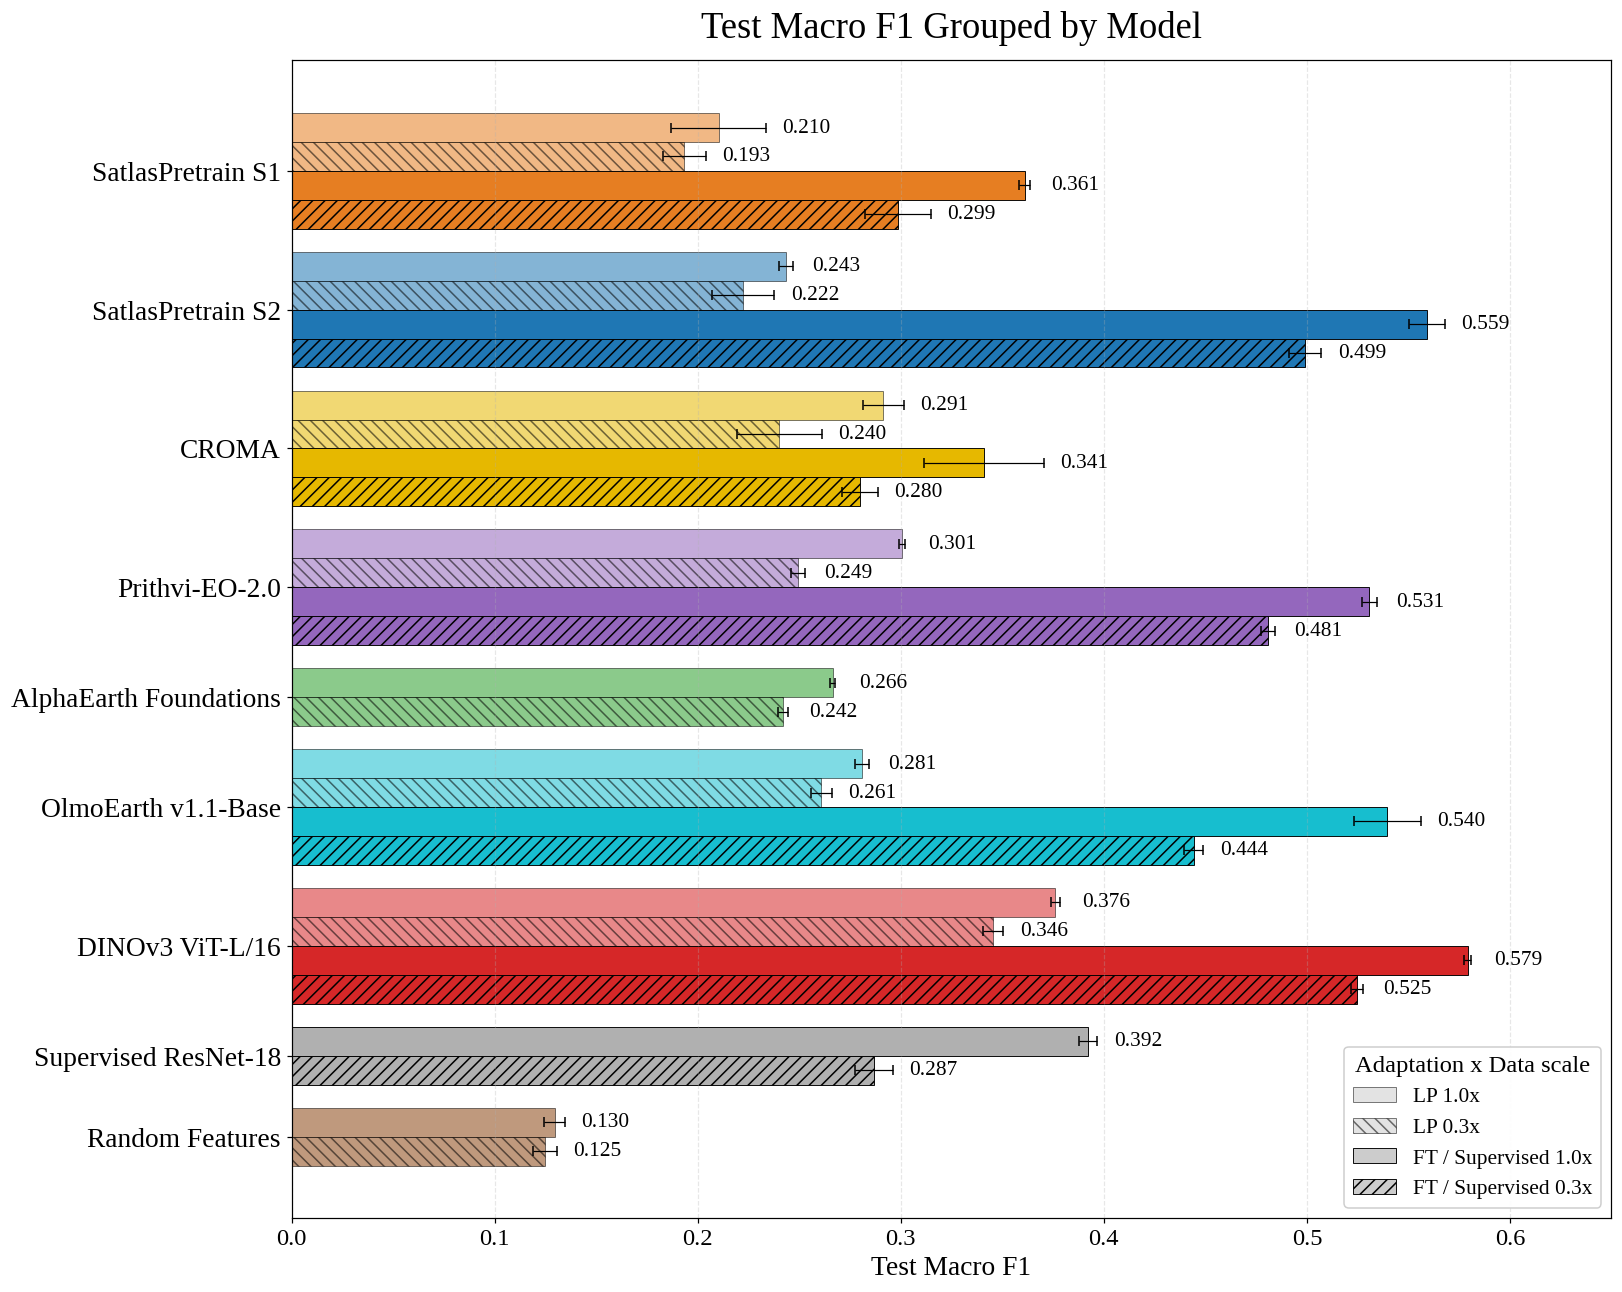

In [10]:
def figure_6_grouped_by_model():
    method_style = {
        ('LP', '1.0x'):  {'alpha': 0.55, 'hatch': ''},
        ('LP', '0.3x'):  {'alpha': 0.55, 'hatch': '\\\\\\'},
        ('FT', '1.0x'):  {'alpha': 1.00, 'hatch': ''},
        ('FT', '0.3x'):  {'alpha': 1.00, 'hatch': '///'},
        ('Sup', '1.0x'): {'alpha': 1.00, 'hatch': ''},
        ('Sup', '0.3x'): {'alpha': 1.00, 'hatch': '///'},
    }
    methods_full   = [('LP', '1.0x'), ('LP', '0.3x'), ('FT', '1.0x'), ('FT', '0.3x')]
    methods_alpha  = [('LP', '1.0x'), ('LP', '0.3x')]
    methods_sup    = [('Sup', '1.0x'), ('Sup', '0.3x')]
    methods_random = [('LP', '1.0x'), ('LP', '0.3x')]

    fig, ax = plt.subplots(figsize=(15, 12))
    bar_h = 0.19
    y_positions, y_labels, y_current = [], [], 0.0

    for fm in FM_ORDER:
        color = FM_COLORS[fm]
        if fm == 'AlphaEarth Foundations':
            methods = methods_alpha
        elif fm == 'Supervised ResNet-18':
            methods = methods_sup
        elif fm == 'Random Features':
            methods = methods_random
        else:
            methods = methods_full

        fm_y_start = y_current
        for meth, frac in methods:
            d = load_agg(fm, meth, frac)
            if d is None:
                continue
            v, s = d['test_macro_f1']['mean'], d['test_macro_f1']['std']
            style = method_style[(meth, frac)]
            ax.barh(y_current, v, height=bar_h, color=color, edgecolor='black',
                    linewidth=0.6, hatch=style['hatch'], alpha=style['alpha'],
                    xerr=s if s > 0 else None,
                    error_kw={'ecolor': 'black', 'capsize': 3, 'linewidth': 0.8})
            ax.text(v + max(s, 0.005) + 0.008, y_current, f'{v:.3f}',
                    va='center', fontsize=14)
            y_current += bar_h
        y_positions.append((fm_y_start + y_current - bar_h) / 2)
        y_labels.append(fm)
        y_current += bar_h * 0.8

    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=18)
    ax.set_xlabel('Test Macro F1', fontsize=18)
    ax.set_xlim(0, 0.65)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    ax.tick_params(axis='x', labelsize=16)
    ax.set_title('Test Macro F1 Grouped by Model', fontsize=24, pad=15)

    style_legend = [
        Patch(facecolor='#cccccc', edgecolor='black', linewidth=0.6, alpha=0.55, label='LP 1.0x'),
        Patch(facecolor='#cccccc', edgecolor='black', linewidth=0.6, alpha=0.55, hatch='\\\\\\', label='LP 0.3x'),
        Patch(facecolor='#cccccc', edgecolor='black', linewidth=0.6, alpha=1.0, label='FT / Supervised 1.0x'),
        Patch(facecolor='#cccccc', edgecolor='black', linewidth=0.6, alpha=1.0, hatch='///', label='FT / Supervised 0.3x'),
    ]
    ax.legend(handles=style_legend, loc='lower right', fontsize=14, framealpha=0.95,
              title='Adaptation x Data scale', title_fontsize=16)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'fig6_grouped_by_model.png', dpi=300, bbox_inches='tight')
    plt.show()

figure_6_grouped_by_model()

### Figure 7 — fine-tuning labels efficiency


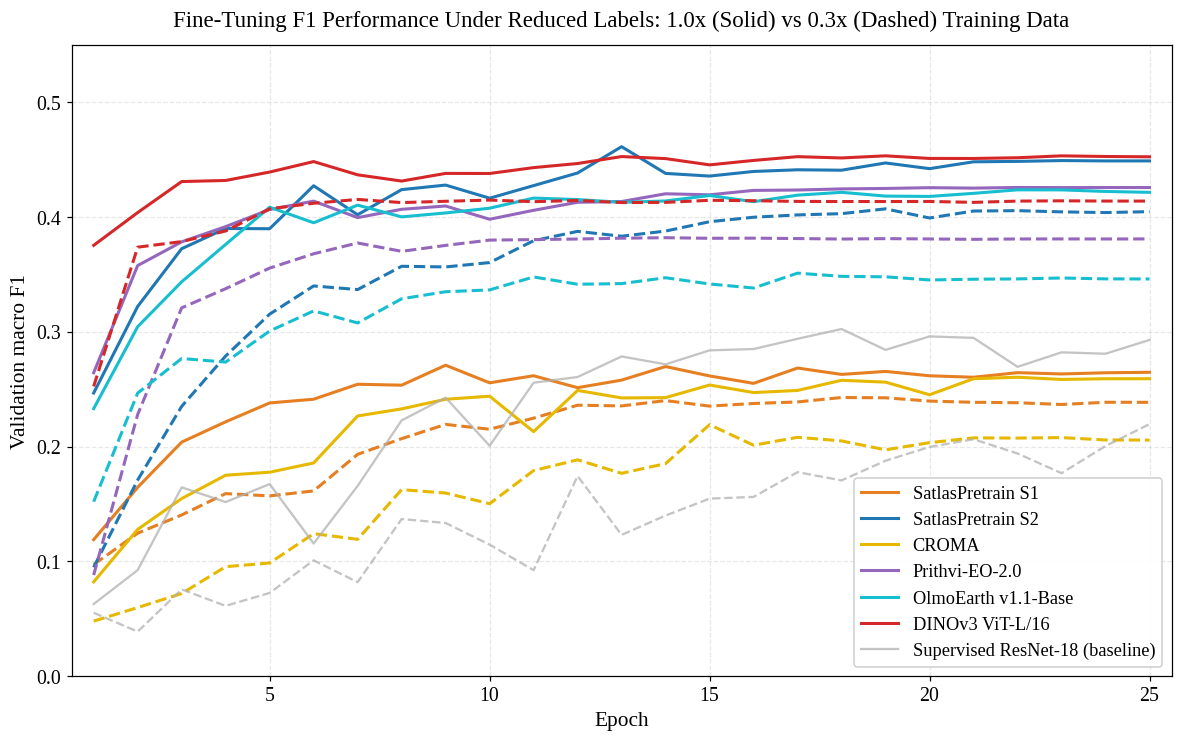

In [11]:
def figure_7_labels_efficiency_ft():
    ft_models = ['SatlasPretrain S1', 'SatlasPretrain S2', 'CROMA',
                 'Prithvi-EO-2.0', 'OlmoEarth v1.1-Base', 'DINOv3 ViT-L/16',
                 'Supervised ResNet-18']
    fig, ax = plt.subplots(figsize=(11, 7))
    for fm in ft_models:
        color = FM_COLORS[fm]
        is_baseline = fm == 'Supervised ResNet-18'
        lw = 1.5 if is_baseline else 2.0
        alpha = 0.75 if is_baseline else 1.0
        subdirs = RUN_DIR_MAP.get(fm, (None, None, None, None))
        ft_1x, ft_3x = subdirs[2], subdirs[3]

        curves = load_val_curves(ft_1x)
        if curves is not None:
            mean_c = curves.mean(axis=0)
            epochs = np.arange(1, len(mean_c) + 1)
            label = f'{fm} (baseline)' if is_baseline else fm
            ax.plot(epochs, mean_c, color=color, linestyle='-', linewidth=lw, alpha=alpha, label=label)

        curves = load_val_curves(ft_3x)
        if curves is not None:
            mean_c = curves.mean(axis=0)
            epochs = np.arange(1, len(mean_c) + 1)
            ax.plot(epochs, mean_c, color=color, linestyle='--', linewidth=lw, alpha=alpha)

    ax.set_xlabel('Epoch', fontsize=14)
    ax.set_ylabel('Validation macro F1', fontsize=14)
    ax.set_title('Fine-Tuning F1 Performance Under Reduced Labels: 1.0x (Solid) vs 0.3x (Dashed) Training Data',
                 fontsize=15, pad=12)
    ax.set_xlim(0.5, 25.5)
    ax.set_ylim(0, 0.55)
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(loc='lower right', fontsize=12, framealpha=0.95)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'fig7_fine-tuning_labels-efficiency.png', dpi=300, bbox_inches='tight')
    plt.show()

figure_7_labels_efficiency_ft()

### Figure 8 — per-sector macro F1


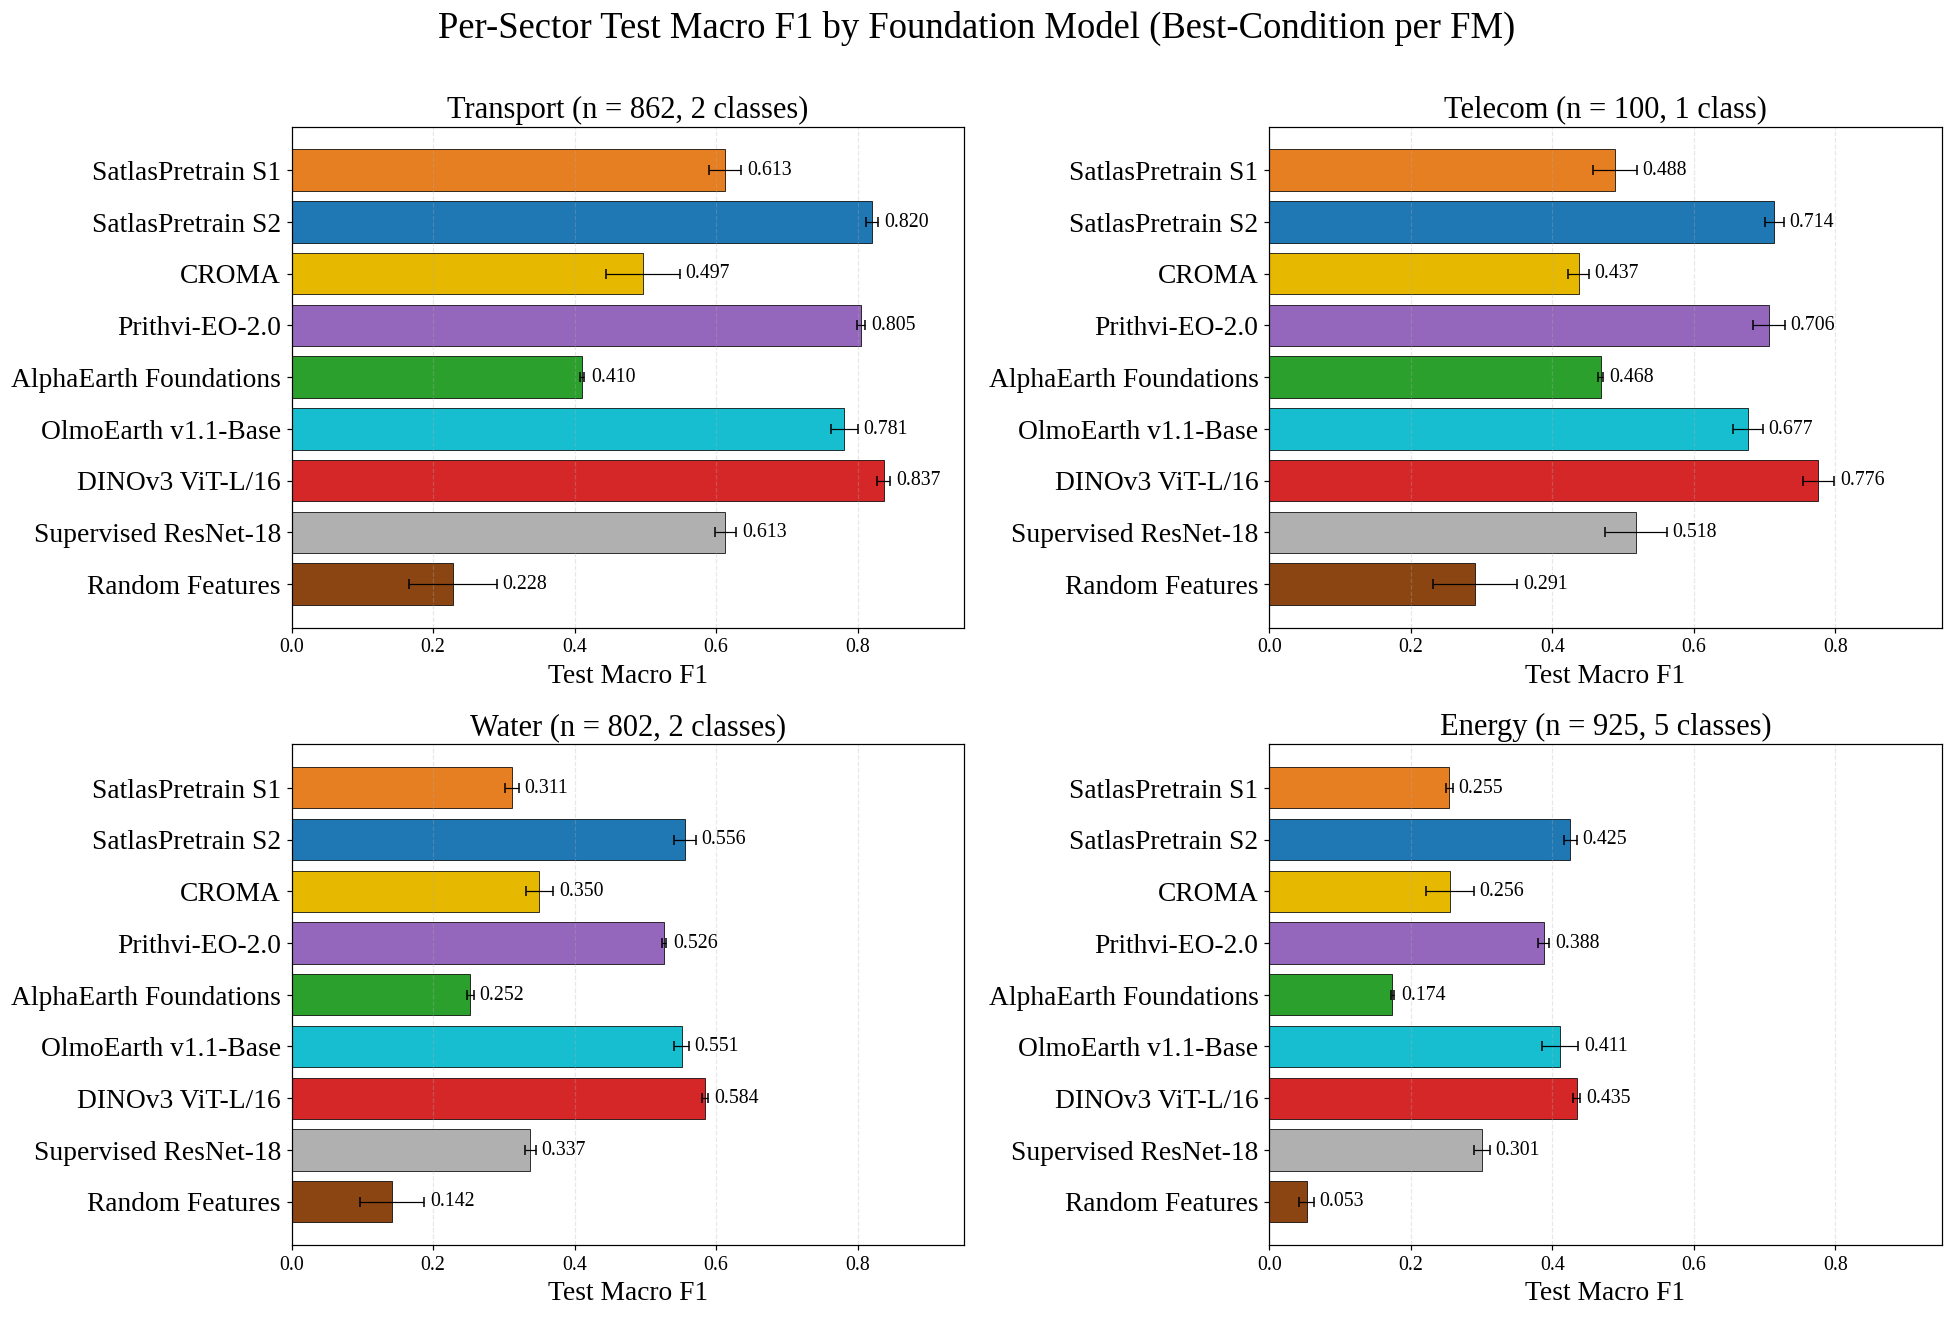

In [12]:
def figure_8_per_sector():
    sectors = [('transport', 'Transport', 862, 2),
               ('telecom',   'Telecom',   100, 1),
               ('water',     'Water',     802, 2),
               ('energy',    'Energy',    925, 5)]
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes_flat = axes.flatten()
    for i, (sec_key, sec_name, n, n_classes) in enumerate(sectors):
        ax = axes_flat[i]
        vals, stds, colors, labels = [], [], [], []
        for fm in FM_ORDER:
            d = _best_condition_agg(fm)
            if d is None:
                continue
            entry = d['per_sector_f1'][sec_key]
            vals.append(entry['mean_macro_f1'])
            stds.append(entry['std_macro_f1'])
            colors.append(FM_COLORS[fm])
            labels.append(fm)
        y_pos = np.arange(len(labels))
        ax.barh(y_pos, vals, xerr=stds, color=colors, edgecolor='black', linewidth=0.5,
                error_kw={'ecolor': 'black', 'capsize': 3, 'linewidth': 0.8})
        for j, (v, s) in enumerate(zip(vals, stds)):
            ax.text(v + max(s, 0.005) + 0.008, j, f'{v:.3f}', va='center', fontsize=13)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=18)
        ax.set_xlim(0, 0.95)
        ax.set_xlabel('Test Macro F1', fontsize=18)
        cls_word = 'class' if n_classes == 1 else 'classes'
        ax.set_title(f'{sec_name} (n = {n}, {n_classes} {cls_word})', fontsize=20)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.invert_yaxis()
    fig.suptitle('Per-Sector Test Macro F1 by Foundation Model (Best-Condition per FM)',
                 fontsize=24, y=1.00)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'fig8_per_sector.png', dpi=300, bbox_inches='tight')
    plt.show()

figure_8_per_sector()

### Figure 9 — per-region macro F1

Reported on the original 13-class taxonomy, unlike every other figure here. The aggregates store per-region F1 already averaged over classes, so there is nothing left to re-average onto the 10-class subset.


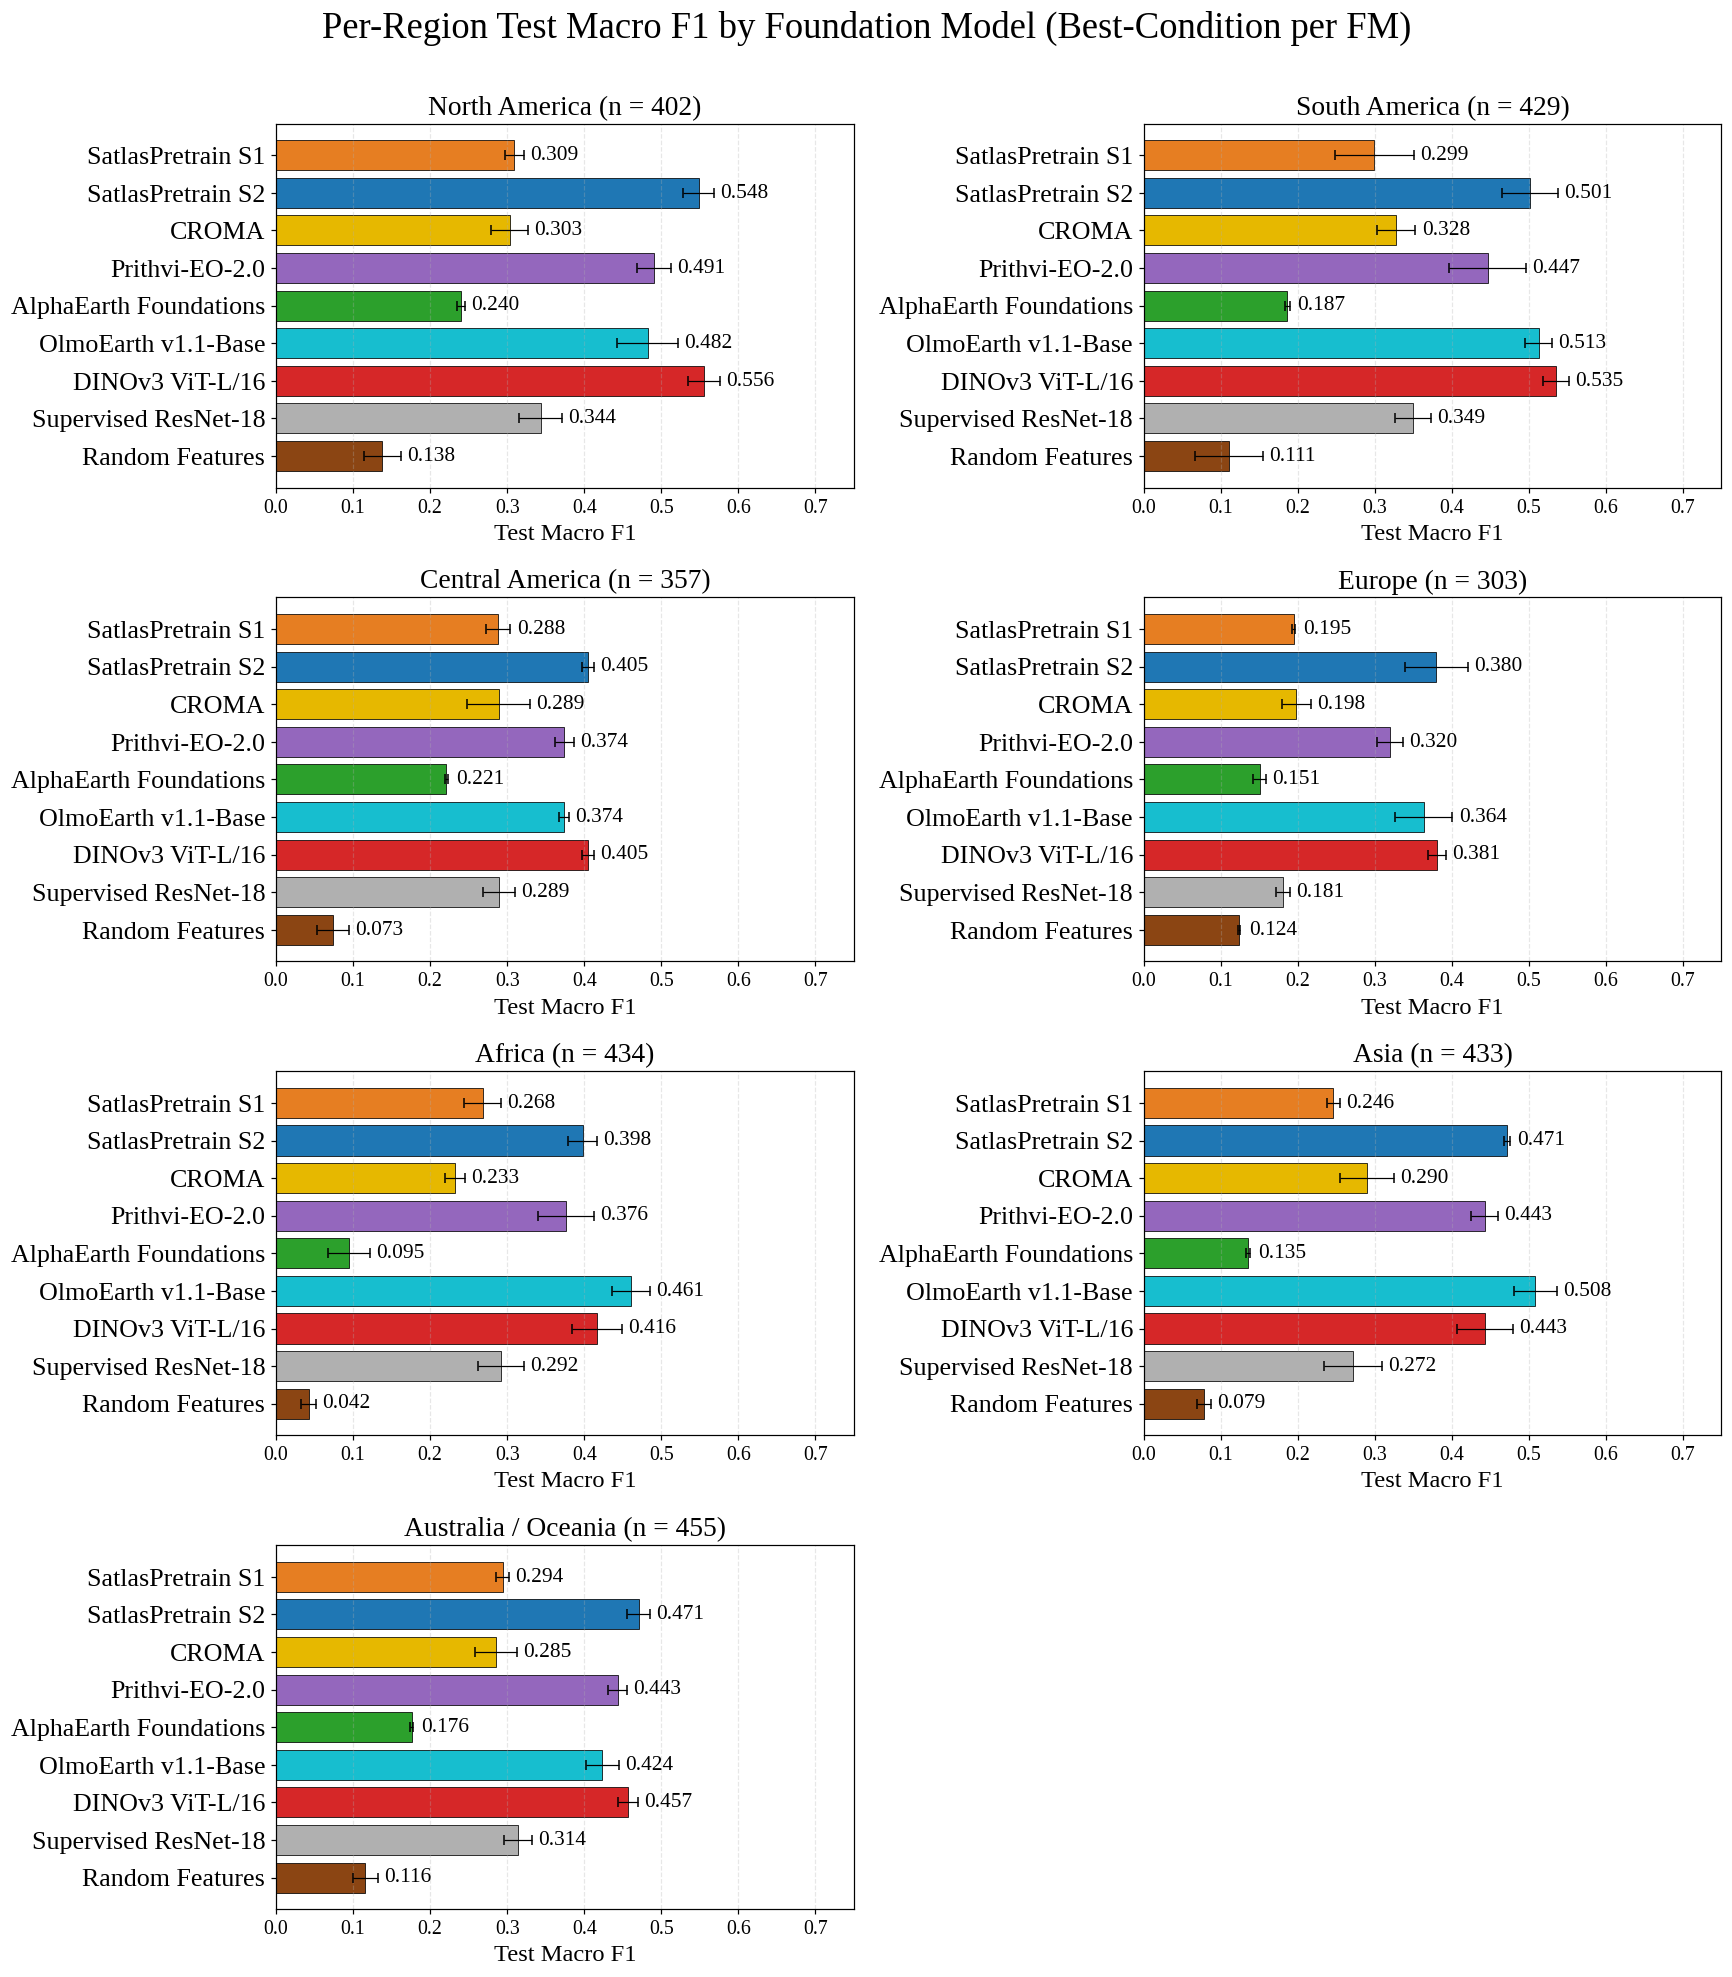

In [13]:
def figure_9_per_region():
    regions = [('north-america',     'North America',       402),
               ('south-america',     'South America',       429),
               ('central-america',   'Central America',     357),
               ('europe',            'Europe',              303),
               ('africa',            'Africa',              434),
               ('asia',              'Asia',                433),
               ('australia-oceania', 'Australia / Oceania', 455)]
    # right-sized from (16,18) -> (13,15) to cut LaTeX downscaling so fonts survive on-page.
    fig, axes = plt.subplots(4, 2, figsize=(16, 18))
    axes_flat = axes.flatten()
    for i, (reg_key, reg_name, n) in enumerate(regions):
        ax = axes_flat[i]
        vals, stds, colors, labels = [], [], [], []
        for fm in FM_ORDER:
            d = _best_condition_agg(fm)
            if d is None:
                continue
            entry = d['per_region_f1'][reg_key]
            vals.append(entry['mean_macro_f1'])
            stds.append(entry['std_macro_f1'])
            colors.append(FM_COLORS[fm])
            labels.append(fm)
        y_pos = np.arange(len(labels))
        ax.barh(y_pos, vals, xerr=stds, color=colors, edgecolor='black', linewidth=0.5,
                error_kw={'ecolor': 'black', 'capsize': 3, 'linewidth': 0.8})
        for j, (v, s) in enumerate(zip(vals, stds)):
            ax.text(v + max(s, 0.005) + 0.008, j, f'{v:.3f}', va='center', fontsize=14)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=17)
        ax.set_xlim(0, 0.75)
        ax.set_xlabel('Test Macro F1', fontsize=16)
        ax.set_title(f'{reg_name} (n = {n})', fontsize=18)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.invert_yaxis()
    axes_flat[7].axis('off')
    fig.suptitle('Per-Region Test Macro F1 by Foundation Model (Best-Condition per FM)',
                 fontsize=24, y=1.00)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'fig9_per_region.png', dpi=300, bbox_inches='tight')
    plt.show()

figure_9_per_region()

### Figures 10 and S10 — training dynamics at 1.0x and 0.3x


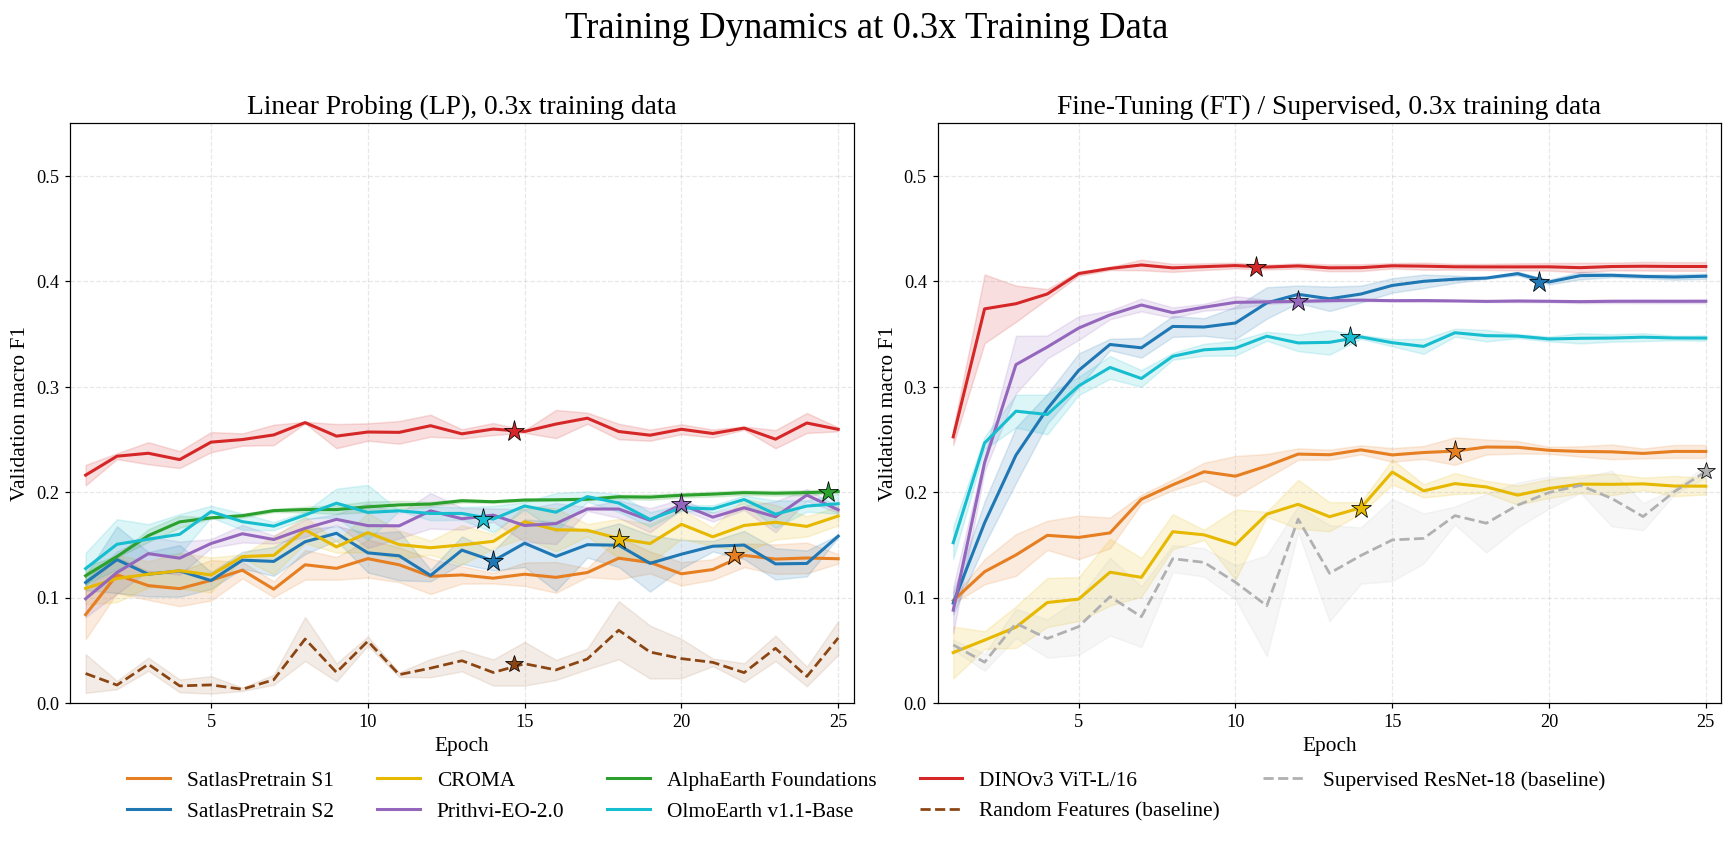

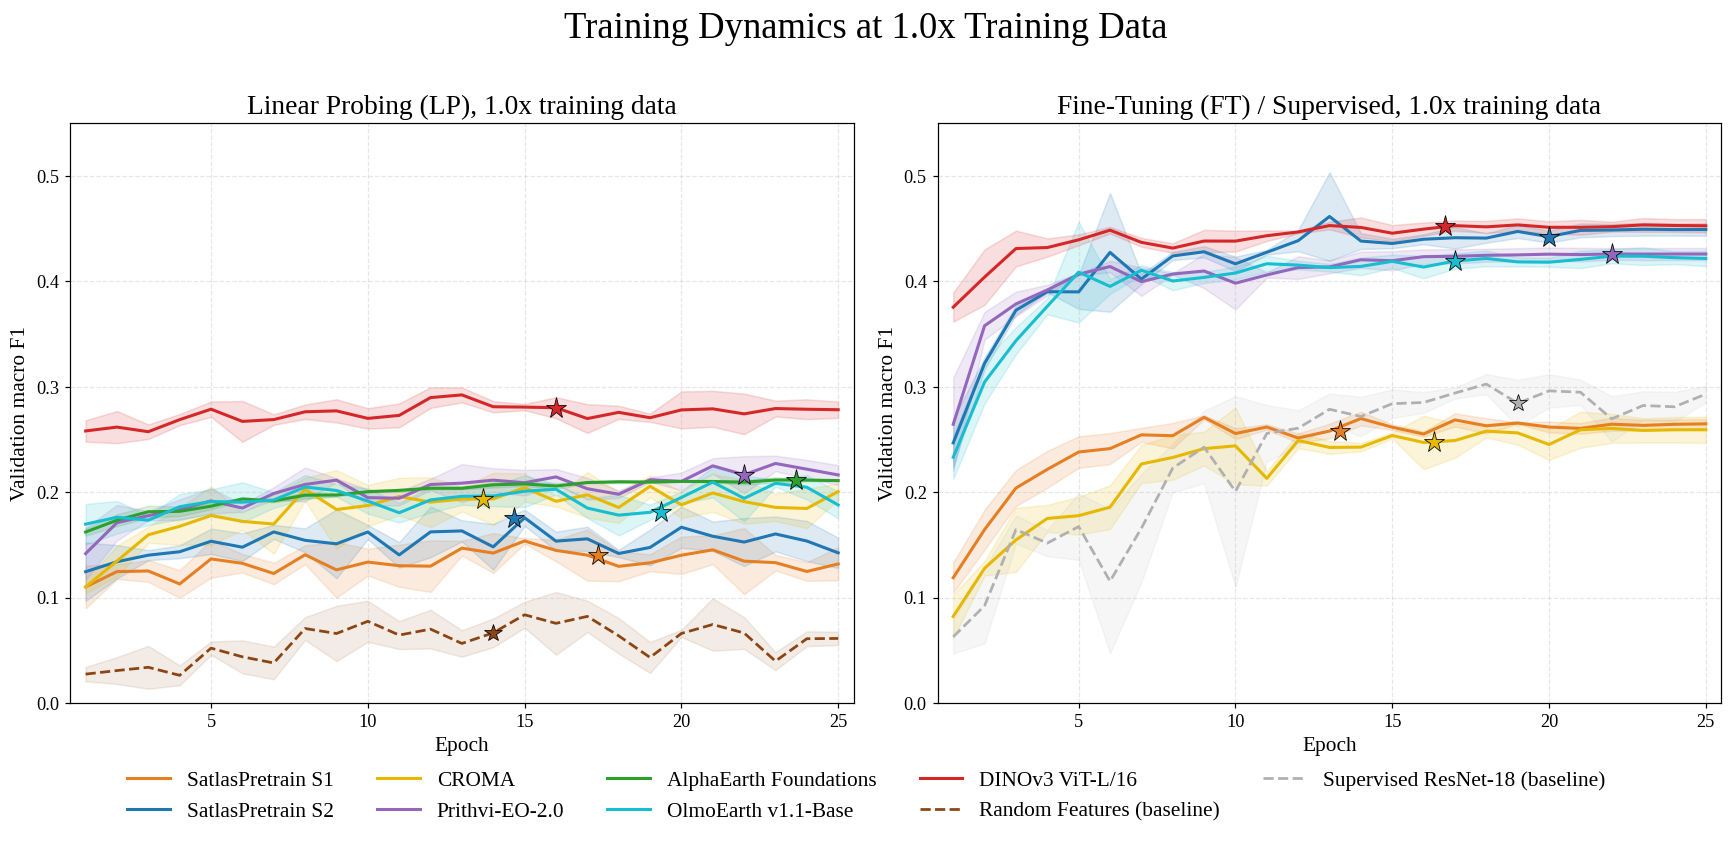

In [14]:
def _training_dynamics_panels(scale, out_name, super_title):
    subdir_lookup = {('LP', '1.0x'): 0, ('LP', '0.3x'): 1, ('FT', '1.0x'): 2, ('FT', '0.3x'): 3}
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for panel_idx, mode in enumerate(['LP', 'FT']):
        ax = axes[panel_idx]
        idx = subdir_lookup[(mode, scale)]
        for fm in FM_ORDER:
            subdirs = RUN_DIR_MAP.get(fm, (None, None, None, None))
            subdir = subdirs[idx]
            curves = load_val_curves(subdir)
            if curves is None:
                continue
            mean_c = curves.mean(axis=0)
            std_c = curves.std(axis=0)
            epochs = np.arange(1, len(mean_c) + 1)
            color = FM_COLORS[fm]
            is_baseline = fm in ('Supervised ResNet-18', 'Random Features')
            linestyle = '--' if is_baseline else '-'
            linewidth = 1.8 if is_baseline else 2.0
            alpha_band = 0.10 if is_baseline else 0.15
            label = f'{fm} (baseline)' if is_baseline else fm
            ax.plot(epochs, mean_c, color=color, linestyle=linestyle, linewidth=linewidth, label=label)
            ax.fill_between(epochs, mean_c - std_c, mean_c + std_c, color=color, alpha=alpha_band)
            be_mean = load_best_epoch_mean(subdir)
            if be_mean is not None and 1 <= be_mean <= len(mean_c):
                bidx = int(round(be_mean)) - 1
                if 0 <= bidx < len(mean_c):
                    ax.plot([be_mean], [mean_c[bidx]], marker='*',
                            markersize=14 if not is_baseline else 12, color=color,
                            markeredgecolor='black', markeredgewidth=0.5, zorder=5)
        panel_label = {
            ('LP', '1.0x'): 'Linear Probing (LP), 1.0x training data',
            ('LP', '0.3x'): 'Linear Probing (LP), 0.3x training data',
            ('FT', '1.0x'): 'Fine-Tuning (FT) / Supervised, 1.0x training data',
            ('FT', '0.3x'): 'Fine-Tuning (FT) / Supervised, 0.3x training data',
        }[(mode, scale)]
        ax.set_xlabel('Epoch', fontsize=14)
        ax.set_ylabel('Validation macro F1', fontsize=14)
        ax.set_title(panel_label, fontsize=18)
        ax.set_xlim(0.5, 25.5)
        ax.set_ylim(0, 0.55)
        ax.grid(alpha=0.3, linestyle='--')
        ax.tick_params(labelsize=12)

    handles, labels = [], []
    for ax in axes:
        h, ll = ax.get_legend_handles_labels()
        for hi, li in zip(h, ll):
            if li not in labels:
                handles.append(hi)
                labels.append(li)
    fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, -0.02),
               ncol=5, fontsize=14, frameon=False)
    fig.suptitle(super_title, fontsize=24, y=1.00)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / out_name, dpi=300, bbox_inches='tight')
    plt.show()


def figure_s10_training_dynamics_03x():
    _training_dynamics_panels('0.3x', 'FigS10_training-dynamics_0.3x.png',
                              'Training Dynamics at 0.3x Training Data')

def figure_10_training_dynamics_10x():
    _training_dynamics_panels('1.0x', 'fig10_training-dynamics_1.0x.png',
                              'Training Dynamics at 1.0x Training Data')

figure_s10_training_dynamics_03x()
figure_10_training_dynamics_10x()

## 3 — Supporting Information: Figures S1–S9

Aggregate confusion matrices, one per model, summed across three seeds. Sliced
from the raw 13x13 per-seed matrices to the 10 retained classes and
row-normalized against the original class supports, so each diagonal percentage
matches that class's recall exactly.


In [15]:
# =========================================================================
# supporting information Figures S1-S9 -- 10-class confusion matrices
# =========================================================================
# ports from evaluation/analysis/confusion_matrices.ipynb. renders each FM's
# aggregate confusion matrix on the 10 retained classes.
#
# method:
#   1. sum raw 13x13 per-seed CMs across seeds.
#   2. slice to 10x10 on KEEP_IDX (rows AND cols).
#   3. row-normalize using ORIGINAL 13-col row sums, so diagonal %
#      equals per-class recall from the 13-class evaluation (which is
#      what the per-class F1 values in Tables S8 and S9 were computed with).
#   4. rows may sum to <100% if the model predicted excluded classes;
#      the missing % is small (<1% for most classes, up to ~8% for
#      wastewater->water_works confusion) and is honestly absent from
#      the display.

# per-FM: (results-subdir, per-seed-file-prefix, display label, protocol_key).
# protocol_key is the JSON top-level wrapper -- 'finetune' for FT-supporting
# FMs, 'linear_probe' for LP-only and for the supervised ResNet-18 (which
# was saved under the linear_probe key even though it is end-to-end trained).
CM_FM_CONFIGS = {
    'satlas_s1':      ('fm_eval_satlas_s1_finetune_v1',        'satlas_s1_finetune_v1',       'SatlasPretrain S1 (FT, 1.0x)',       'finetune'),
    'satlas_s2':      ('fm_eval_satlas_s2_finetune_v1',        'satlas_s2_finetune_v1',       'SatlasPretrain S2 (FT, 1.0x)',       'finetune'),
    'croma':          ('fm_eval_croma_finetune_v1',            'croma_finetune_v1',           'CROMA (FT, 1.0x)',                   'finetune'),
    'prithvi':        ('fm_eval_prithvi_finetune_v1',          'prithvi_finetune_v1',         'Prithvi-EO-2.0 (FT, 1.0x)',          'finetune'),
    'alphaearth':     ('fm_eval_alphaearth_v2_spatial',        'alphaearth_v2',               'AlphaEarth Foundations (LP, 1.0x)',  'linear_probe'),
    'olmoearth':      ('fm_eval_olmoearth_finetune_v1',        'olmoearth_finetune_v1',       'OlmoEarth v1.1-Base (FT, 1.0x)',     'finetune'),
    'dinov3':         ('fm_eval_dinov3_finetune_v1',           'dinov3_finetune_v1',          'DINOv3 ViT-L/16 (FT, 1.0x)',         'finetune'),
    'resnet':         ('fm_eval_resnet18_supervised_v1',       'resnet18_supervised_v1',      'Supervised ResNet-18',               'linear_probe'),
    'random_features':('fm_eval_resnet18_random_features_v1',  'resnet18_random_features_v1', 'Random Features (LP, 1.0x)',         'linear_probe'),
}

DEFAULT_CM_SEEDS = [314, 271, 161]

# output stems, matching the filenames the supporting information uses.
_SI_FIGURE_NAMES = {
    'satlas_s1':      'FigS1_satlas_s1',
    'satlas_s2':      'FigS2_satlas_s2',
    'croma':          'FigS3_croma',
    'prithvi':        'FigS4_prithvi',
    'alphaearth':     'FigS5_alphaearth',
    'olmoearth':      'FigS6_olmo',
    'dinov3':         'FigS7_dino',
    'resnet':         'FigS8_resnet',
    'random_features':'FigS9_random_features',
}


def _load_cm_per_seed(fm, seeds=DEFAULT_CM_SEEDS):
    """Load per-seed 13x13 confusion matrices + per-class F1s for one FM."""
    if fm not in CM_FM_CONFIGS:
        raise ValueError(f'Unknown FM "{fm}". Options: {list(CM_FM_CONFIGS)}')
    subdir, prefix, label, protocol_key = CM_FM_CONFIGS[fm]
    results_dir = RESULTS_BASE / subdir
    per_seed, missing = {}, []
    for s in seeds:
        p = results_dir / f'{prefix}_seed{s}_results.json'
        if not p.exists():
            missing.append(s); continue
        with open(p) as f:
            r = json.load(f)
        test = r[protocol_key]['test']
        per_seed[s] = {
            'cm_13':           np.array(test['confusion'], dtype=np.int64),
            'per_class_f1_13': test['per_class_f1'],
        }
    return per_seed, missing, label


def _slice_cm_to_10class(cm_13):
    """Slice 13x13 -> 10x10 on KEEP_IDX; row-normalize using original 13-col
    row sums so diagonal cells equal per-class recall on the retained set."""
    cm_10 = cm_13[np.ix_(KEEP_IDX, KEEP_IDX)]
    original_row_sums = cm_13[KEEP_IDX].sum(axis=1, keepdims=True).astype(np.float64)
    cm_10_norm = np.divide(
        cm_10.astype(np.float64),
        original_row_sums,
        out=np.zeros_like(cm_10, dtype=np.float64),
        where=original_row_sums > 0,
    )
    return cm_10, cm_10_norm


def _draw_confusion_10(ax, cm_10, cm_10_norm, title, cmap='Oranges'):
    im = ax.imshow(cm_10_norm, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(CLASS_DISPLAY_NAMES_10, rotation=45, ha='right', fontsize=14)
    ax.set_yticklabels(CLASS_DISPLAY_NAMES_10, fontsize=14)
    ax.set_xlabel('Predicted', fontsize=17)
    ax.set_ylabel('True',      fontsize=17)
    ax.set_title(title, fontsize=18)
    for i in range(10):
        for j in range(10):
            v = cm_10_norm[i, j]
            if v > 0.01:
                color = 'white' if v > 0.5 else 'black'
                weight = 'bold' if i == j else 'normal'
                ax.text(j, i, f'{int(cm_10[i, j])}\n({v:.0%})',
                        ha='center', va='center', color=color, fontsize=16, fontweight=weight)
    return im


def confusion_matrix_aggregate_10class(fm, seeds=DEFAULT_CM_SEEDS,
                                        cmap='Oranges', save=False):
    """Render one aggregate 10-class confusion matrix inline.

    seeds       : which seeds to sum over (default 314/271/161)
    cmap        : matplotlib colormap (default 'Oranges')
    save=True   : also writes to OUTPUTS_DIR / '{FigS<n>_<model>}.png'
    """
    per_seed, missing, label = _load_cm_per_seed(fm, seeds)
    if missing:
        print(f'NOTE: missing seeds {missing} for {label}')
    available = [s for s in seeds if s in per_seed]
    if not available:
        print(f'NO SEEDS AVAILABLE for {label}; skipping')
        return None

    cm_13_sum = sum(per_seed[s]['cm_13'] for s in available)
    cm_10, cm_10_norm = _slice_cm_to_10class(cm_13_sum)

    # 10-class macro F1 = mean over KEEP_IDX per-class F1s, per seed, then avg seeds
    macros = [float(np.mean([per_seed[s]['per_class_f1_13'][i] for i in KEEP_IDX]))
              for s in available]
    macro_mean = float(np.mean(macros))
    macro_std  = float(np.std(macros, ddof=0))

    # n = retained-class true samples across seeds (= 2689 * n_seeds)
    n_retained = int(sum(cm_13_sum[i].sum() for i in KEEP_IDX))

    title = (f'n = {n_retained} across {len(available)} seeds\n'
             f'macro F1 = {macro_mean:.3f} \u00b1 {macro_std:.3f}')

    fig, ax = plt.subplots(1, 1, figsize=(13, 12.5), constrained_layout=True)
    im = _draw_confusion_10(ax, cm_10, cm_10_norm, title, cmap=cmap)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                 label='Row-normalized (over original 13-class row sums)')
    fig.suptitle(f'{label} \u2014 Aggregate Confusion Matrix (10 classes)',
                 fontsize=20, y=1.01)

    if save:
        out = OUTPUTS_DIR / f'{_SI_FIGURE_NAMES[fm]}.png'
        fig.savefig(out, dpi=300, bbox_inches='tight')
        print(f'  saved {out}')

    plt.show()
    return per_seed


def save_all_confusion_matrices_10class(fms=None, seeds=DEFAULT_CM_SEEDS,
                                          cmap='Oranges', dpi=300):
    """Bulk-save all 9 aggregate 10-class confusion matrices to OUTPUTS_DIR.

    Writes as OUTPUTS_DIR / 'FigS<n>_<model>.png' (numbering matches paper).
    Does NOT render inline -- fills up notebook memory otherwise.
    """
    if fms is None:
        fms = list(CM_FM_CONFIGS.keys())
    written = []
    for fm in fms:
        per_seed, missing, label = _load_cm_per_seed(fm, seeds)
        if missing:
            print(f'[{label}] missing seeds {missing}')
        available = [s for s in seeds if s in per_seed]
        if not available:
            print(f'[{label}] NO SEEDS AVAILABLE; skipping'); continue

        cm_13_sum = sum(per_seed[s]['cm_13'] for s in available)
        cm_10, cm_10_norm = _slice_cm_to_10class(cm_13_sum)
        macros = [float(np.mean([per_seed[s]['per_class_f1_13'][i] for i in KEEP_IDX]))
                  for s in available]
        macro_mean, macro_std = float(np.mean(macros)), float(np.std(macros, ddof=0))
        n_retained = int(sum(cm_13_sum[i].sum() for i in KEEP_IDX))
        title = (f'n = {n_retained} across {len(available)} seeds\n'
                 f'macro F1 = {macro_mean:.3f} \u00b1 {macro_std:.3f}')

        fig, ax = plt.subplots(1, 1, figsize=(13, 12.5), constrained_layout=True)
        im = _draw_confusion_10(ax, cm_10, cm_10_norm, title, cmap=cmap)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                     label='Row-normalized (over original 13-class row sums)')
        fig.suptitle(f'{label} \u2014 Aggregate Confusion Matrix (10 classes)',
                     fontsize=20, y=1.01)
        out = OUTPUTS_DIR / f'{_SI_FIGURE_NAMES[fm]}.png'
        fig.savefig(out, dpi=dpi, bbox_inches='tight')
        plt.close(fig)
        written.append(out)
        print(f'  saved {out}')

    print(f'\nDone. Wrote {len(written)} PNGs to {OUTPUTS_DIR}/')
    return written

print('10-class confusion matrix helpers ready.')
print('  Inline single:  confusion_matrix_aggregate_10class("dinov3")')
print('  Save all nine:  save_all_confusion_matrices_10class()')

10-class confusion matrix helpers ready.
  Inline single:  confusion_matrix_aggregate_10class("dinov3")
  Save all nine:  save_all_confusion_matrices_10class()


In [16]:
# bulk-save all 9 aggregate confusion matrices as PNGs into OUTPUTS_DIR.
# filenames: FigS1_satlas_s1.png ... FigS9_random_features.png
_ = save_all_confusion_matrices_10class()

  saved /content/drive/MyDrive/infra_fm/results/figures/FigS1_satlas_s1.png
  saved /content/drive/MyDrive/infra_fm/results/figures/FigS2_satlas_s2.png
  saved /content/drive/MyDrive/infra_fm/results/figures/FigS3_croma.png
  saved /content/drive/MyDrive/infra_fm/results/figures/FigS4_prithvi.png
  saved /content/drive/MyDrive/infra_fm/results/figures/FigS5_alphaearth.png
  saved /content/drive/MyDrive/infra_fm/results/figures/FigS6_olmo.png
  saved /content/drive/MyDrive/infra_fm/results/figures/FigS7_dino.png
  saved /content/drive/MyDrive/infra_fm/results/figures/FigS8_resnet.png
  saved /content/drive/MyDrive/infra_fm/results/figures/FigS9_random_features.png

Done. Wrote 9 PNGs to /content/drive/MyDrive/infra_fm/results/figures/


## 4 — Supporting Information: Tables S10–S13

Recomputes accuracy (S10), macro precision (S11), macro recall (S12), and
weighted precision (S13) on the 10-class subset, from the per-seed confusion
matrices rather than from the stored aggregates.


In [17]:
# =========================================================================
# supporting information Tables S10-S13 -- recompute on the 10-class subset
# =========================================================================
# slices each per-seed 13x13 CM to 10x10 on KEEP_IDX, then computes:
#   - accuracy           = sum(diag_10) / sum(retained supports)
#   - macro_precision    = mean_i TP_i / (retained predictions of class i)
#   - macro_recall       = mean_i TP_i / (support_i)    [original 13-col row sums]
#   - weighted_precision = sum_i support_i * precision_i / sum_i support_i
#
# recall uses ORIGINAL row sums (= class supports) so per-class recall
# matches Tables S8/S9 and Figures S1-S9. precision uses SLICED
# column sums (predictions restricted to retained classes). accuracy
# denominator = sum of retained supports (2689 per seed), which preserves
# the "weighted recall = accuracy" identity in Table F1's caption.

import glob

# JSON top-level wrapper key varies. supervised ResNet-18 saved under
# 'linear_probe' even though it's end-to-end trained.
PROTOCOL_WRAPPER = {
    ('SatlasPretrain S1',      'LP'):  'linear_probe',
    ('SatlasPretrain S1',      'FT'):  'finetune',
    ('SatlasPretrain S2',      'LP'):  'linear_probe',
    ('SatlasPretrain S2',      'FT'):  'finetune',
    ('CROMA',                  'LP'):  'linear_probe',
    ('CROMA',                  'FT'):  'finetune',
    ('Prithvi-EO-2.0',         'LP'):  'linear_probe',
    ('Prithvi-EO-2.0',         'FT'):  'finetune',
    ('AlphaEarth Foundations', 'LP'):  'linear_probe',
    ('OlmoEarth v1.1-Base',    'LP'):  'linear_probe',
    ('OlmoEarth v1.1-Base',    'FT'):  'finetune',
    ('DINOv3 ViT-L/16',        'LP'):  'linear_probe',
    ('DINOv3 ViT-L/16',        'FT'):  'finetune',
    ('Supervised ResNet-18',   'Sup'): 'linear_probe',   # SupRN-18 wrapper is linear_probe
    ('Random Features',        'LP'):  'linear_probe',
}


def _compute_10class_metrics_from_cm(cm_13):
    """Return dict of 10-class metrics from one 13x13 confusion matrix."""
    cm_10 = cm_13[np.ix_(KEEP_IDX, KEEP_IDX)]
    tp = np.diag(cm_10).astype(np.float64)
    row_sums_orig = cm_13[KEEP_IDX].sum(axis=1).astype(np.float64)  # original supports
    col_sums_10   = cm_10.sum(axis=0).astype(np.float64)             # retained predictions

    recall_10 = np.divide(tp, row_sums_orig,
                          out=np.zeros_like(tp), where=row_sums_orig > 0)
    precision_10 = np.divide(tp, col_sums_10,
                             out=np.zeros_like(tp), where=col_sums_10 > 0)

    total_retained = float(row_sums_orig.sum())   # = 2689 per seed
    if total_retained <= 0:
        return {'accuracy': 0.0, 'macro_precision': 0.0,
                'macro_recall': 0.0, 'weighted_precision': 0.0}

    return {
        'accuracy':           float(tp.sum() / total_retained),
        'macro_precision':    float(precision_10.mean()),
        'macro_recall':       float(recall_10.mean()),
        'weighted_precision': float((row_sums_orig * precision_10).sum() / total_retained),
    }


def _load_per_seed_cms(fm, mode, scale, seeds=(314, 271, 161)):
    """Load per-seed 13x13 CMs for a condition. Returns list (may be shorter than seeds)."""
    idx = _MODE_SCALE_TO_IDX.get((mode, scale))
    if idx is None:
        return []
    subdirs = RUN_DIR_MAP.get(fm)
    if subdirs is None or subdirs[idx] is None:
        return []
    wrapper_key = PROTOCOL_WRAPPER.get((fm, mode))
    if wrapper_key is None:
        return []

    cms = []
    for seed in seeds:
        pattern = str(RESULTS_BASE / subdirs[idx] / f'*_seed{seed}_results.json')
        matches = glob.glob(pattern)
        if not matches:
            continue
        with open(matches[0]) as f:
            r = json.load(f)
        cm = np.array(r[wrapper_key]['test']['confusion'], dtype=np.int64)
        cms.append(cm)
    return cms


def compute_si_metric_tables_10class():
    """Compute all 30 conditions' 10-class metrics.

    Returns dict[(fm, mode, scale)] -> {metric: (mean, pop_std)}.
    """
    conditions = [
        ('SatlasPretrain S1',      'LP', '1.0x'),
        ('SatlasPretrain S1',      'LP', '0.3x'),
        ('SatlasPretrain S1',      'FT', '1.0x'),
        ('SatlasPretrain S1',      'FT', '0.3x'),
        ('SatlasPretrain S2',      'LP', '1.0x'),
        ('SatlasPretrain S2',      'LP', '0.3x'),
        ('SatlasPretrain S2',      'FT', '1.0x'),
        ('SatlasPretrain S2',      'FT', '0.3x'),
        ('CROMA',                  'LP', '1.0x'),
        ('CROMA',                  'LP', '0.3x'),
        ('CROMA',                  'FT', '1.0x'),
        ('CROMA',                  'FT', '0.3x'),
        ('Prithvi-EO-2.0',         'LP', '1.0x'),
        ('Prithvi-EO-2.0',         'LP', '0.3x'),
        ('Prithvi-EO-2.0',         'FT', '1.0x'),
        ('Prithvi-EO-2.0',         'FT', '0.3x'),
        ('AlphaEarth Foundations', 'LP', '1.0x'),
        ('AlphaEarth Foundations', 'LP', '0.3x'),
        ('OlmoEarth v1.1-Base',    'LP', '1.0x'),
        ('OlmoEarth v1.1-Base',    'LP', '0.3x'),
        ('OlmoEarth v1.1-Base',    'FT', '1.0x'),
        ('OlmoEarth v1.1-Base',    'FT', '0.3x'),
        ('DINOv3 ViT-L/16',        'LP', '1.0x'),
        ('DINOv3 ViT-L/16',        'LP', '0.3x'),
        ('DINOv3 ViT-L/16',        'FT', '1.0x'),
        ('DINOv3 ViT-L/16',        'FT', '0.3x'),
        ('Supervised ResNet-18',   'Sup', '1.0x'),
        ('Supervised ResNet-18',   'Sup', '0.3x'),
        ('Random Features',        'LP',  '1.0x'),
        ('Random Features',        'LP',  '0.3x'),
    ]

    results = {}
    for cond in conditions:
        fm, mode, scale = cond
        cms = _load_per_seed_cms(fm, mode, scale)
        if not cms:
            print(f'  MISSING  {fm:<26} {mode:<3} {scale}')
            continue
        per_seed = [_compute_10class_metrics_from_cm(cm) for cm in cms]
        agg = {}
        for metric_name in ('accuracy', 'macro_precision', 'macro_recall', 'weighted_precision'):
            vals = [m[metric_name] for m in per_seed]
            # ddof=0 (population std) to match paper convention
            agg[metric_name] = (float(np.mean(vals)), float(np.std(vals, ddof=0)))
        results[cond] = agg
    return results


# ---- pretty-printer that outputs table-friendly rows ----
def print_si_metric_tables(results):
    metrics = [
        ('accuracy',            'Table F1: Accuracy (= Weighted Recall)'),
        ('macro_precision',     'Table F2: Macro Precision'),
        ('macro_recall',        'Table F3: Macro Recall'),
        ('weighted_precision',  'Table F4: Weighted Precision'),
    ]
    fm_order = [
        'SatlasPretrain S1',
        'SatlasPretrain S2',
        'CROMA',
        'Prithvi-EO-2.0',
        'AlphaEarth Foundations',
        'OlmoEarth v1.1-Base',
        'DINOv3 ViT-L/16',
        'Supervised ResNet-18',
        'Random Features',
    ]

    def cell(fm, mode, scale, metric):
        actual_mode = 'Sup' if fm == 'Supervised ResNet-18' else mode
        cond = (fm, actual_mode, scale)
        if cond not in results:
            return '---'
        mu, sd = results[cond][metric]
        return f'{mu:.3f} +/- {sd:.3f}'

    for metric_key, table_label in metrics:
        print('\n' + '=' * 80)
        print(table_label)
        print('=' * 80)
        print(f'{"FM":<26}  {"LP 1.0x":<15}  {"LP 0.3x":<15}  {"FT 1.0x":<15}  {"FT 0.3x":<15}')
        print('-' * 100)
        for fm in fm_order:
            row = f'{fm:<26}  '
            for mode, scale in [('LP', '1.0x'), ('LP', '0.3x'), ('FT', '1.0x'), ('FT', '0.3x')]:
                row += f'{cell(fm, mode, scale, metric_key):<15}  '
            print(row)


# ---- run ----
print('Computing 10-class Tables S10-S13 from per-seed CMs...\n')
_si_metric_tables = compute_si_metric_tables_10class()
print_si_metric_tables(_si_metric_tables)

Computing 10-class Tables S10-S13 from per-seed CMs...


Table F1: Accuracy (= Weighted Recall)
FM                          LP 1.0x          LP 0.3x          FT 1.0x          FT 0.3x        
----------------------------------------------------------------------------------------------------
SatlasPretrain S1           0.290 +/- 0.027  0.219 +/- 0.018  0.384 +/- 0.010  0.342 +/- 0.024  
SatlasPretrain S2           0.323 +/- 0.016  0.294 +/- 0.017  0.595 +/- 0.018  0.546 +/- 0.006  
CROMA                       0.309 +/- 0.028  0.275 +/- 0.032  0.336 +/- 0.029  0.297 +/- 0.015  
Prithvi-EO-2.0              0.331 +/- 0.011  0.277 +/- 0.008  0.583 +/- 0.003  0.530 +/- 0.012  
AlphaEarth Foundations      0.275 +/- 0.001  0.271 +/- 0.001  ---              ---              
OlmoEarth v1.1-Base         0.289 +/- 0.007  0.285 +/- 0.025  0.571 +/- 0.029  0.473 +/- 0.012  
DINOv3 ViT-L/16             0.403 +/- 0.011  0.363 +/- 0.003  0.625 +/- 0.004  0.573 +/- 0.001  
Supervised ResNet-18        0